In [1]:
import numpy as np
import pandas as pd 
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
Id=df['Id']

In [4]:
df.drop('Id',axis=1,inplace =True)

In [5]:
df.shape

(1460, 80)

In [6]:
# prof=ProfileReport(df)
# prof.to_file(output_file="Dataset overview.html")

In [7]:
X=df.drop('SalePrice',axis=1)
y=df['SalePrice']

In [8]:
df.isnull().sum()

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64

In [9]:
X.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

## Dataset description

SalePrice - the property's sale price in dollars. This is the target variable that you're trying to predict.  
MSSubClass: The building class  
MSZoning: The general zoning classification  
LotFrontage: Linear feet of street connected to property  
LotArea: Lot size in square feet  
Street: Type of road access  
Alley: Type of alley access  
LotShape: General shape of property  
LandContour: Flatness of the property  
Utilities: Type of utilities available  
LotConfig: Lot configuration  
LandSlope: Slope of property  
Neighborhood: Physical locations within Ames city limits  
Condition1: Proximity to main road or railroad  
Condition2: Proximity to main road or railroad (if a second is present)  
BldgType: Type of dwelling  
HouseStyle: Style of dwelling  
OverallQual: Overall material and finish quality  
OverallCond: Overall condition rating  
YearBuilt: Original construction date  
YearRemodAdd: Remodel date  
RoofStyle: Type of roof  
RoofMatl: Roof material  
Exterior1st: Exterior covering on house  
Exterior2nd: Exterior covering on house (if more than one material)  
MasVnrType: Masonry veneer type  
MasVnrArea: Masonry veneer area in square feet  
ExterQual: Exterior material quality  
ExterCond: Present condition of the material on the exterior  
Foundation: Type of foundation  
BsmtQual: Height of the basement  
BsmtCond: General condition of the basement  
BsmtExposure: Walkout or garden level basement walls  
BsmtFinType1: Quality of basement finished area  
BsmtFinSF1: Type 1 finished square feet  
BsmtFinType2: Quality of second finished area (if present)  
BsmtFinSF2: Type 2 finished square feet  
BsmtUnfSF: Unfinished square feet of basement area  
TotalBsmtSF: Total square feet of basement area  
Heating: Type of heating  
HeatingQC: Heating quality and condition  
CentralAir: Central air conditioning  
Electrical: Electrical system  
1stFlrSF: First Floor square feet  
2ndFlrSF: Second floor square feet  
LowQualFinSF: Low quality finished square feet (all floors)  
GrLivArea: Above grade (ground) living area square feet  
BsmtFullBath: Basement full bathrooms  
BsmtHalfBath: Basement half bathrooms  
FullBath: Full bathrooms above grade  
HalfBath: Half baths above grade  
Bedroom: Number of bedrooms above basement level  
Kitchen: Number of kitchens  
KitchenQual: Kitchen quality  
TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)  
Functional: Home functionality rating  
Fireplaces: Number of fireplaces  
FireplaceQu: Fireplace quality  
GarageType: Garage location  
GarageYrBlt: Year garage was built  
GarageFinish: Interior finish of the garage  
GarageCars: Size of garage in car capacity  
GarageArea: Size of garage in square feet  
GarageQual: Garage quality  
GarageCond: Garage condition  
PavedDrive: Paved driveway  
WoodDeckSF: Wood deck area in square feet  
OpenPorchSF: Open porch area in square feet  
EnclosedPorch: Enclosed porch area in square feet  
3SsnPorch: Three season porch area in square feet  
ScreenPorch: Screen porch area in square feet  
PoolArea: Pool area in square feet  
PoolQC: Pool quality  
Fence: Fence quality  
MiscFeature: Miscellaneous feature not covered in other categories  
MiscVal: $Value of miscellaneous feature  
MoSold: Month Sold  
YrSold: Year Sold  
SaleType: Type of sale  
SaleCondition: Condition of sale  


In [10]:
df['OverallQual']

0       7
1       6
2       7
3       7
4       8
       ..
1455    6
1456    6
1457    7
1458    5
1459    5
Name: OverallQual, Length: 1460, dtype: int64

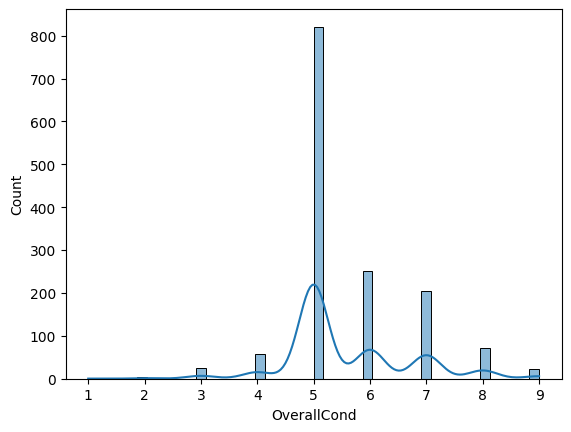

In [11]:
sns.histplot(x='OverallCond',data=df,kde=True)
plt.show()

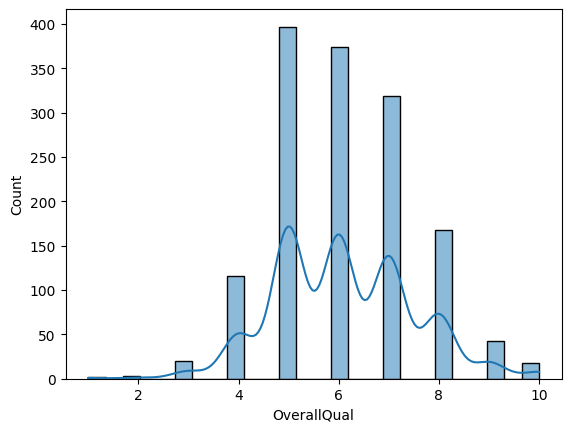

In [12]:
sns.histplot(x='OverallQual',data=df,kde=True)
plt.show()

In [13]:
QualXCond=df['OverallQual']*df['OverallCond']

In [14]:
QualXCond

0       35
1       48
2       35
3       35
4       40
        ..
1455    30
1456    36
1457    63
1458    30
1459    30
Length: 1460, dtype: int64

In [15]:
X['QualXCond']=QualXCond
X.drop(columns={'OverallQual','OverallCond'},axis=1,inplace=True)

In [16]:
X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,QualXCond
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,35
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,48
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,35
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,35
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,40


Feature engineering for the columns 

RoofStyle: Type of roof  
RoofMatl: Roof material

In [17]:
print(X['RoofStyle'].isnull().sum())
print(X['RoofMatl'].isnull().sum())

0
0


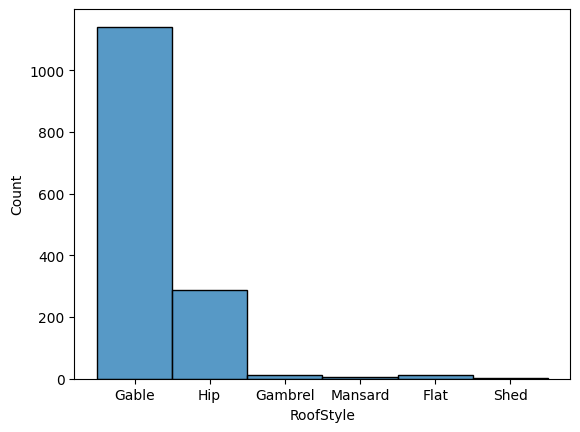

In [18]:
sns.histplot(x='RoofStyle',data=df)
plt.show()

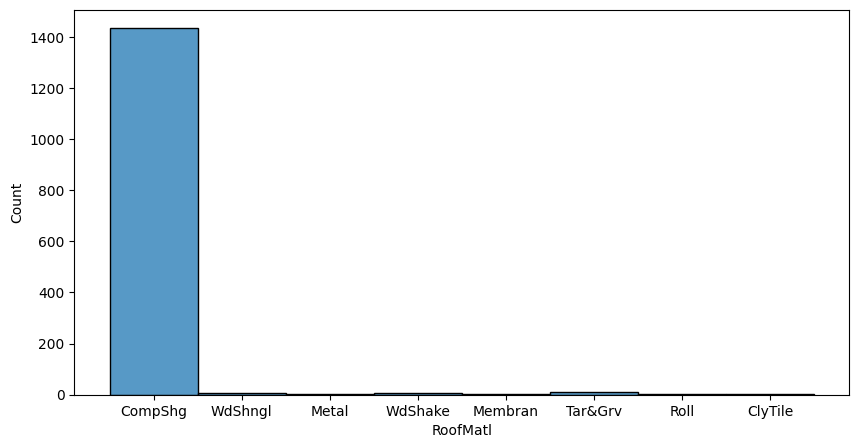

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(x='RoofMatl',data=df)
plt.show()

In [20]:
df[X['RoofMatl']=='Tar&Grv']

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
367,80,RL,101.0,9150,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,165000
457,20,RL,NaN,53227,Pave,NaN,IR1,Low,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,3,2008,WD,Normal,256000
466,20,RL,85.0,10628,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdWo,NaN,0,4,2007,WD,Normal,167000
588,20,RL,65.0,25095,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2009,WD,Partial,143000
666,60,RL,NaN,18450,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Abnorml,129000
828,60,RL,NaN,28698,Pave,NaN,IR2,Low,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,6,2009,WD,Abnorml,185000
888,20,RL,95.0,15865,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,10,2007,WD,Normal,268000
934,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,Inside,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
954,90,RL,35.0,9400,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,10,2006,WD,AdjLand,127500
1000,20,RL,74.0,10206,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,82000


In [21]:
df[X['RoofMatl']=='WdShngl']

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
53,20,RL,68.0,50271,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,385000
185,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,Inside,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
451,20,RL,62.0,70761,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,280000
629,80,RL,82.0,9020,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,GdPrv,NaN,0,6,2008,WD,Normal,168500
691,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1044,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,7,2009,WD,Normal,278000


In [22]:
# Replacing with median price weight 

X['RoofMatl']= X['RoofMatl'] .map({
    'ClyTile' :   1.600,
    'CompShg'    :1.620,
    'Membran'   : 2.415,
    'Metal'    :  1.800,
    'Roll'       :1.370,
    'Tar&Grv'   : 1.570,
    'WdShake'    :2.420,
    'WdShngl'   : 3.325
    
})

In [23]:
df.groupby('RoofMatl')['SalePrice'].median()/100000

RoofMatl
ClyTile    1.600
CompShg    1.620
Membran    2.415
Metal      1.800
Roll       1.370
Tar&Grv    1.670
WdShake    2.420
WdShngl    3.325
Name: SalePrice, dtype: float64

In [24]:
df[X['RoofStyle']=='Gable']

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,20,FV,62.0,7500,Pave,Pave,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,185000
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


In [25]:
df[df['RoofStyle']=='Shed']

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1230,90,RL,NaN,18890,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,Gar2,8300,8,2007,WD,Normal,190000
1270,40,RL,NaN,23595,Pave,NaN,Reg,Low,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,260000


In [26]:
# Replacing with median price weight 

X['RoofStyle']= X['RoofStyle'] .map({
    'Flat'    :   1.650,
    'Gable'     : 1.600,
    'Gambrel'    :1.190,
    'Hip'      :  1.765,
    'Mansard'   : 1.550,
    'Shed'       :2.250
    
})

since the price of the **Roll** type matches with CompShg i.e can be grouped with CompShg 

In [27]:
X['RoofStyle'].unique()

array([1.6  , 1.765, 1.19 , 1.55 , 1.65 , 2.25 ])

In [28]:
df.groupby('RoofStyle')['SalePrice'].median()/100000

RoofStyle
Flat       1.850
Gable      1.600
Gambrel    1.390
Hip        1.765
Mansard    1.750
Shed       2.250
Name: SalePrice, dtype: float64

In [29]:
X['Roof_qual']=X['RoofStyle']*X['RoofMatl']
X['Roof_qual']

0       2.5920
1       2.5920
2       2.5920
3       2.5920
4       2.5920
         ...  
1455    2.5920
1456    2.5920
1457    2.5920
1458    2.8593
1459    2.5920
Name: Roof_qual, Length: 1460, dtype: float64

In [30]:
X.drop(columns={'RoofStyle','RoofMatl'},axis=1,inplace=True)

In [31]:
X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,2,2008,WD,Normal,35,2.592
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,5,2007,WD,Normal,48,2.592
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,9,2008,WD,Normal,35,2.592
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,35,2.592
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,12,2008,WD,Normal,40,2.592


In [32]:
X.sample(10)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual
421,20,RL,NaN,16635,Pave,NaN,IR1,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,6,2009,WD,Normal,42,2.5920
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,2,2008,WD,Normal,35,2.5920
1302,60,RL,92.0,10120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,12,2006,WD,Normal,40,2.8593
745,60,RL,NaN,8963,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,7,2008,WD,Normal,72,2.8593
1329,60,RL,63.0,9084,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,6,2006,WD,Normal,35,2.8593
279,60,RL,83.0,10005,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,3,2008,WD,Normal,35,2.8593
97,20,RL,73.0,10921,Pave,NaN,Reg,HLS,AllPub,Inside,...,NaN,NaN,NaN,0,5,2007,WD,Normal,20,2.8593
343,120,RL,63.0,8849,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,7,2008,WD,Normal,45,2.8593
577,80,RL,96.0,11777,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,5,2006,WD,Abnorml,30,2.5920
109,20,RL,105.0,11751,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,MnPrv,NaN,0,1,2010,COD,Normal,36,2.8593


Exterior1st: Exterior covering on house  
Exterior2nd: Exterior covering on house (if more than one material)  

In [33]:
(df.groupby('Exterior1st')['SalePrice'].median()/100000).round(2)

Exterior1st
AsbShng    1.08
AsphShn    1.00
BrkComm    0.71
BrkFace    1.66
CBlock     1.05
CemntBd    2.37
HdBoard    1.50
ImStucc    2.62
MetalSd    1.39
Plywood    1.67
Stone      2.58
Stucco     1.44
VinylSd    2.00
Wd Sdng    1.39
WdShing    1.29
Name: SalePrice, dtype: float64

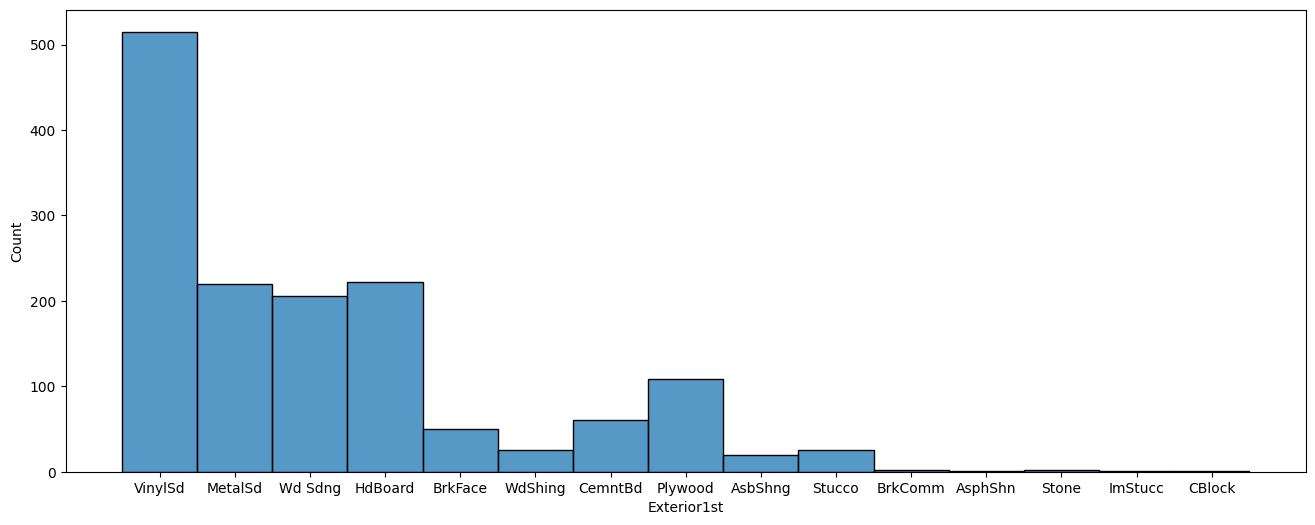

In [34]:
plt.figure(figsize=(16,6))
sns.histplot(x='Exterior1st',data=df)
plt.show()

In [35]:
X['Exterior1st']=X['Exterior1st'].map({
    'AsbShng':    1.080,
    'AsphShn'  :  1.000,
    'BrkComm'  :  0.710,
    'BrkFace' :   1.657,
    'CBlock'  :   1.050,
    'CemntBd'  :  2.365,
    'HdBoard'  :  1.499,
    'ImStucc'  :  2.620,
    'MetalSd'  :  1.390,
    'Plywood'  :  1.674,
    'Stone'     : 2.585,
    'Stucco'   :  1.440,
    'VinylSd'  :  2.000,
    'Wd Sdng'   : 1.389,
    'WdShing'  :  1.287
})

In [36]:
X['Exterior1st']

0       2.000
1       1.390
2       2.000
3       1.389
4       2.000
        ...  
1455    2.000
1456    1.674
1457    2.365
1458    1.390
1459    1.499
Name: Exterior1st, Length: 1460, dtype: float64

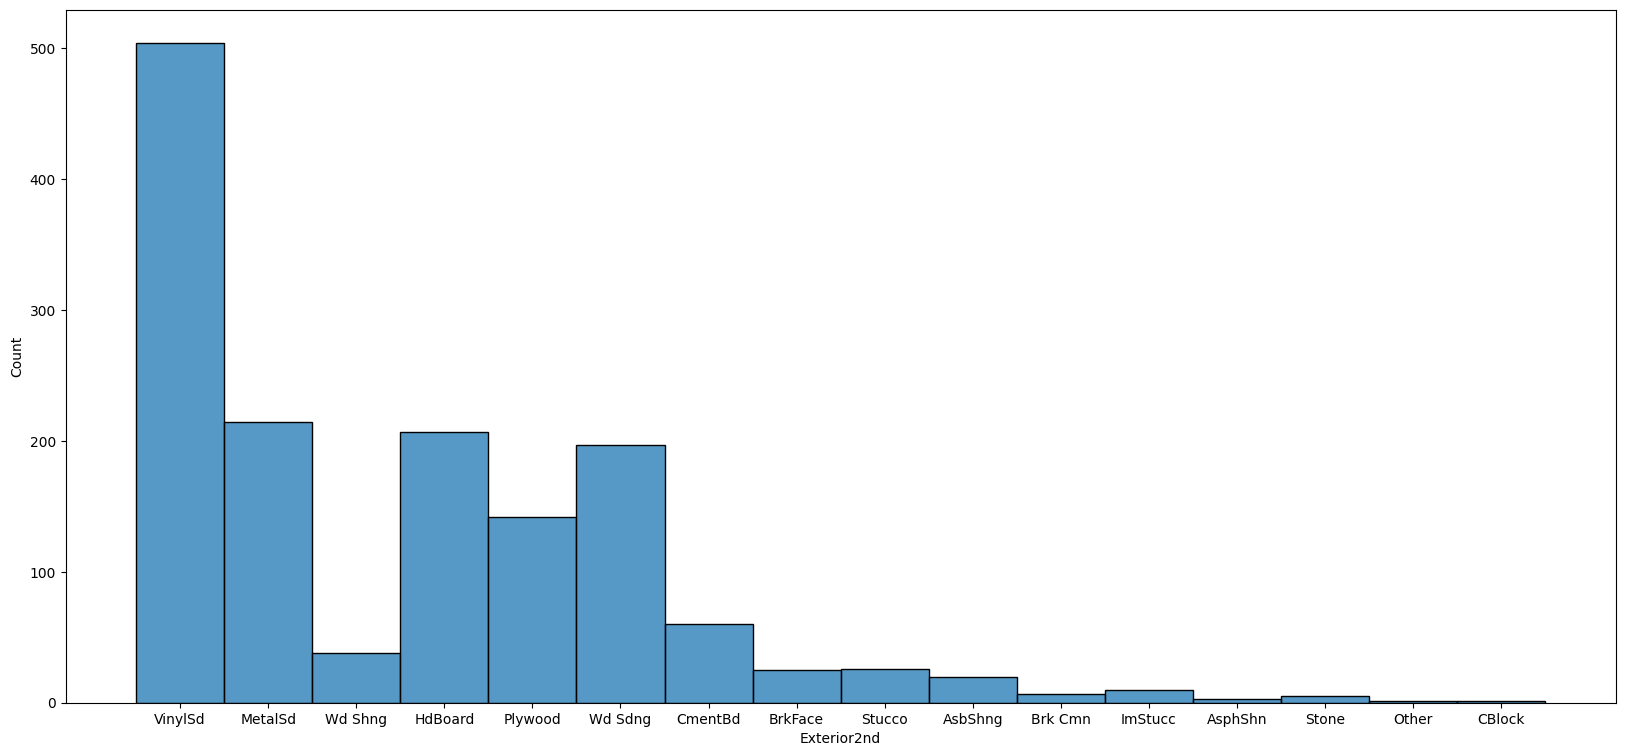

In [37]:
plt.figure(figsize=(20,9))
sns.histplot(x='Exterior2nd',data=df)
plt.show()

In [38]:
X['Exterior2nd']=X['Exterior2nd'].map({
    'AsbShng'  :  1.110,
    'AsphShn'   : 1.390,
    'Brk Cmn'   : 1.470,
    'BrkFace'   : 1.600,
    'CBlock'    : 1.050,
    'CmentBd'  :  2.387,
    'HdBoard'  :  1.550,
    'ImStucc'  :  1.876,
    'MetalSd'  :  1.387,
    'Other'    :  3.190,
    'Plywood'  :  1.607,
    'Stone'    :  1.770,
    'Stucco'   :  1.420,
    'VinylSd'  :  2.000,
    'Wd Sdng'  :  1.380,
    'Wd Shng'  :  1.382,
})



In [39]:
X['Exterior2nd']

0       2.000
1       1.387
2       2.000
3       1.382
4       2.000
        ...  
1455    2.000
1456    1.607
1457    2.387
1458    1.387
1459    1.550
Name: Exterior2nd, Length: 1460, dtype: float64

In [40]:
X['Exterior']=(X['Exterior1st']*X['Exterior2nd']).round(2)
X.drop(columns={'Exterior1st','Exterior2nd'},axis=1,inplace=True)

0.6473509279597882
count    1460.000000
mean        2.942192
std         1.069031
min         1.040000
25%         1.930000
50%         2.410000
75%         4.000000
max         6.380000
Name: Exterior, dtype: float64


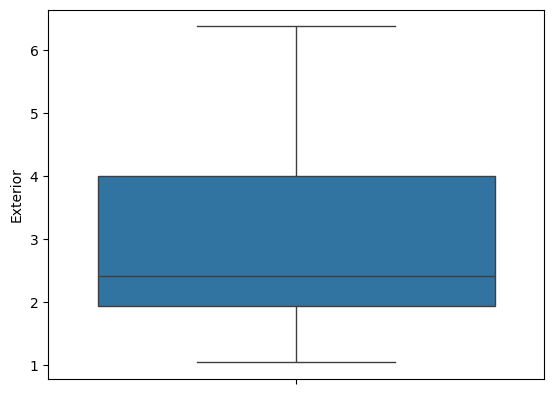

In [41]:
print(X['Exterior'].skew()) # right skewed
print(X['Exterior'].describe())
sns.boxplot(X['Exterior'])
plt.show()

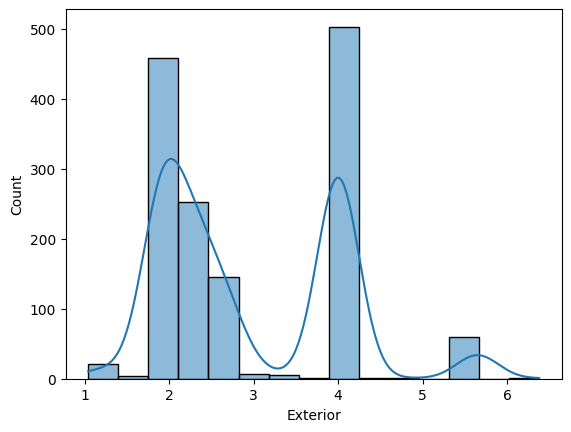

In [42]:
sns.histplot(X['Exterior'],kde=True)
plt.show()

In [43]:
X['Exterior'].isnull().sum()

0

In [44]:
X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual,Exterior
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,0,2,2008,WD,Normal,35,2.592,4.00
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,NaN,NaN,0,5,2007,WD,Normal,48,2.592,1.93
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,0,9,2008,WD,Normal,35,2.592,4.00
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,0,2,2006,WD,Abnorml,35,2.592,1.92
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,NaN,NaN,0,12,2008,WD,Normal,40,2.592,4.00


In [45]:
X.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'YearBuilt', 'YearRemodAdd', 'MasVnrType', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'P

**Condition1**: Proximity to main road or railroad  
**Condition2**: Proximity to main road or railroad (if a second is present)

0
count     1460
unique       9
top       Norm
freq      1260
Name: Condition1, dtype: object


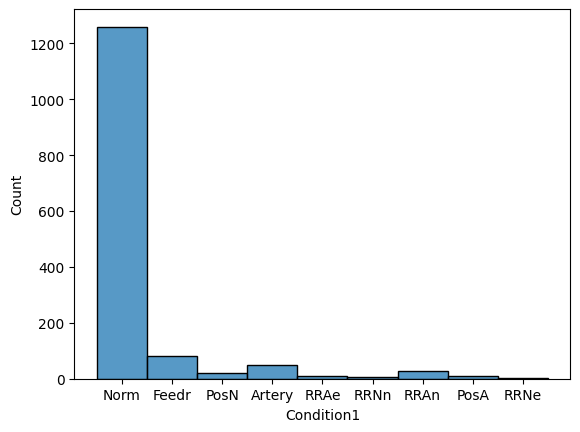

In [46]:
print(X['Condition1'].isnull().sum())
print(X['Condition1'].describe())
sns.histplot(bins=50,x='Condition1',data=X)
plt.show()

In [47]:
(df.groupby('Condition1')['SalePrice'].median()/100000).round(2),X['Condition1'].value_counts()

(Condition1
 Artery    1.20
 Feedr     1.40
 Norm      1.66
 PosA      2.12
 PosN      2.00
 RRAe      1.42
 RRAn      1.71
 RRNe      1.91
 RRNn      2.14
 Name: SalePrice, dtype: float64,
 Condition1
 Norm      1260
 Feedr       81
 Artery      48
 RRAn        26
 PosN        19
 RRAe        11
 PosA         8
 RRNn         5
 RRNe         2
 Name: count, dtype: int64)

0
count     1460
unique       8
top       Norm
freq      1445
Name: Condition2, dtype: object


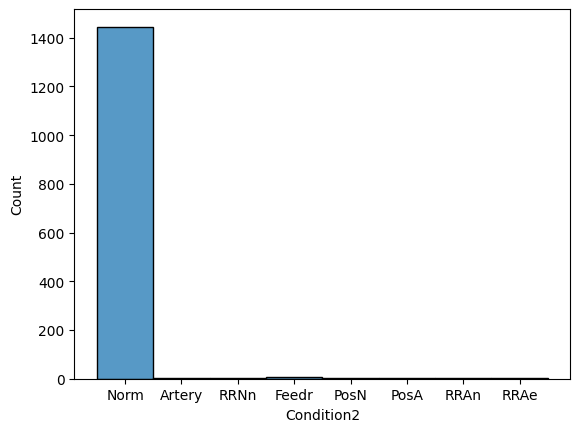

In [48]:
print(X['Condition2'].isnull().sum())
print(X['Condition2'].describe())
sns.histplot(bins=50,x='Condition2',data=X)
plt.show()

In [49]:
X.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'YearBuilt', 'YearRemodAdd', 'MasVnrType', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'P

In [50]:
X.iloc[:,2].isnull().sum()

259

In [51]:
X.columns[0]

'MSSubClass'

# Columns with nans

In [52]:
for i in range(len(X.columns)):
    p=X.iloc[:,i].isnull().sum()
    if p:
        print(X.columns[i],p)

LotFrontage 259
Alley 1369
MasVnrType 872
MasVnrArea 8
BsmtQual 37
BsmtCond 37
BsmtExposure 38
BsmtFinType1 37
BsmtFinType2 38
Electrical 1
FireplaceQu 690
GarageType 81
GarageYrBlt 81
GarageFinish 81
GarageQual 81
GarageCond 81
PoolQC 1453
Fence 1179
MiscFeature 1406


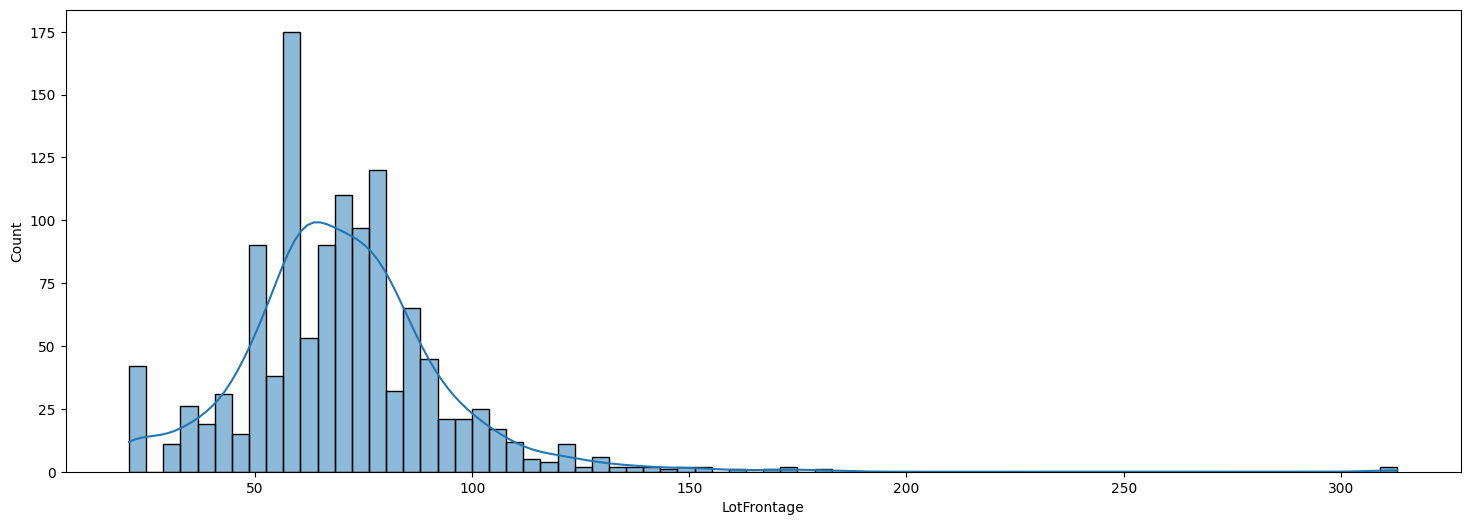

In [53]:
X['LotFrontage']
plt.figure(figsize=(18,6))
sns.histplot(x='LotFrontage',data=X,kde=True)
plt.show()

Right skewed


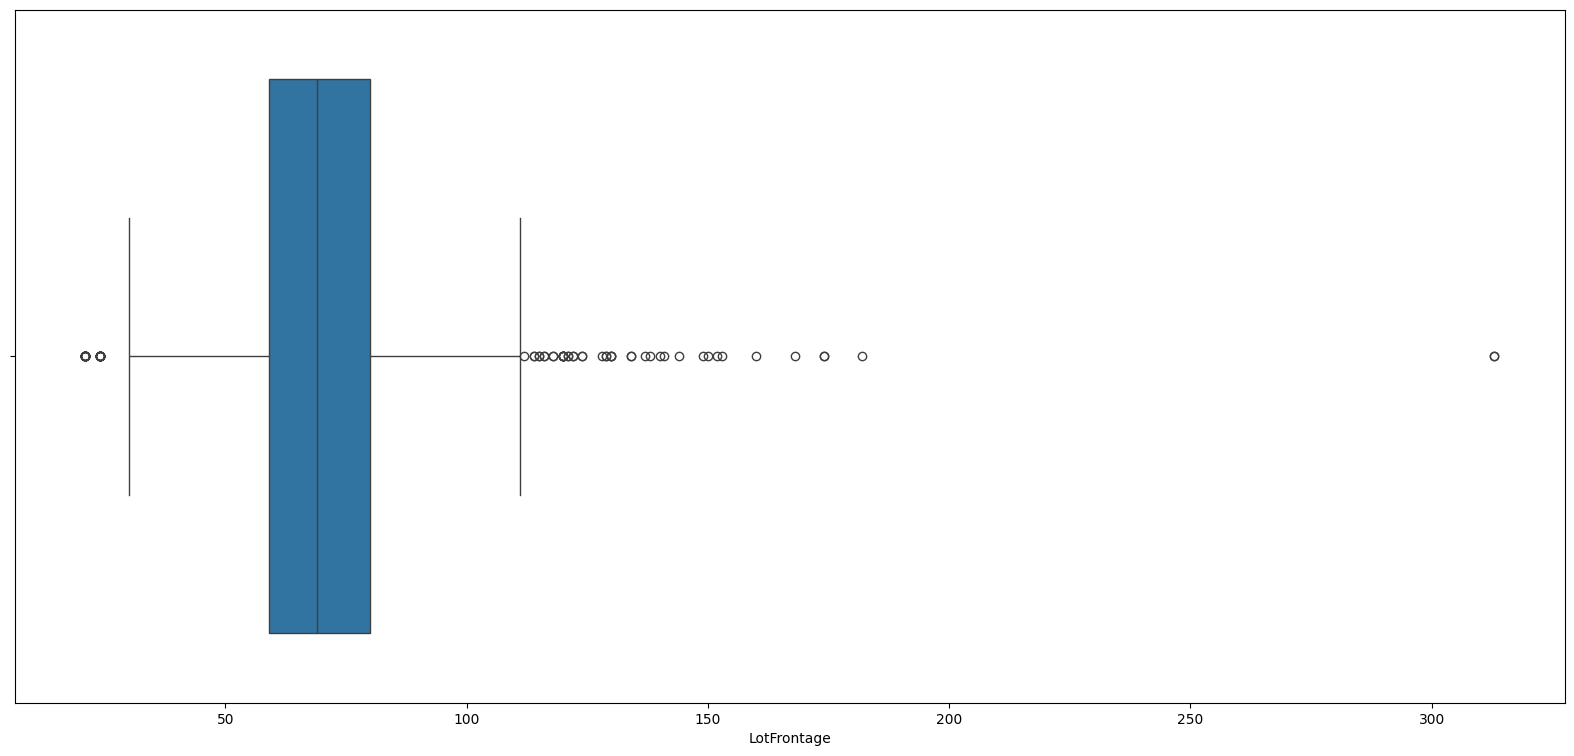

In [54]:
# If the result of X[column1].skew() is very close to 0, use the Mean. If it's far from 0, use the Median.
if X['LotFrontage'].skew()>1:
    print("Right skewed") 
plt.figure(figsize=(20,9))
sns.boxplot(x="LotFrontage",data =X)
plt.show()

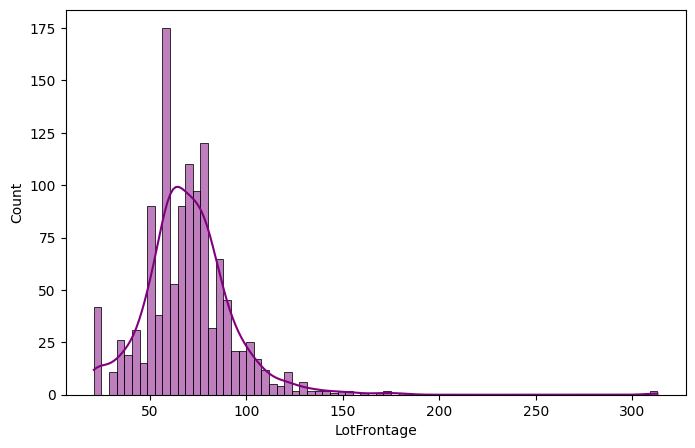

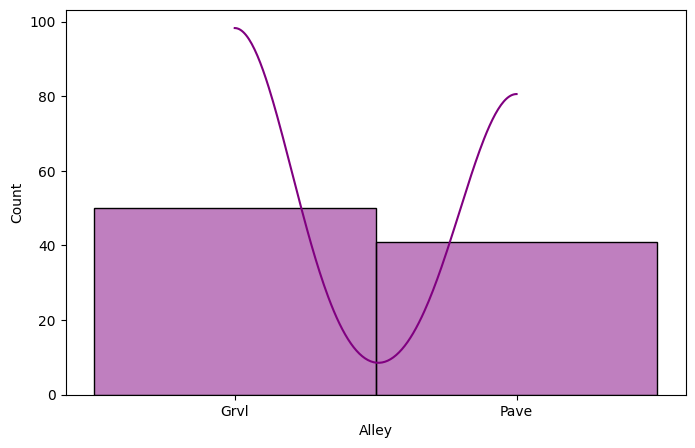

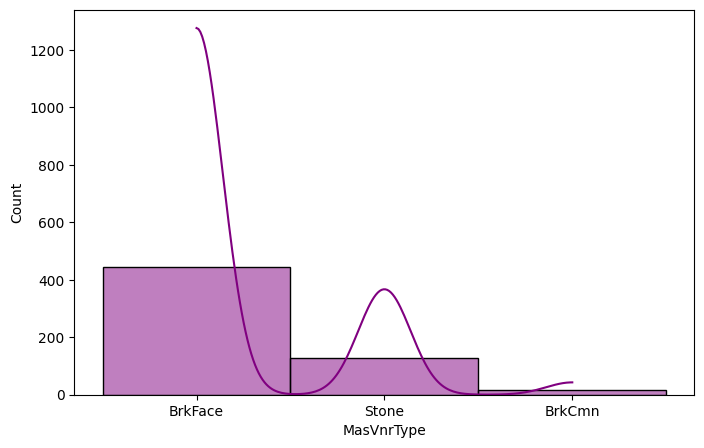

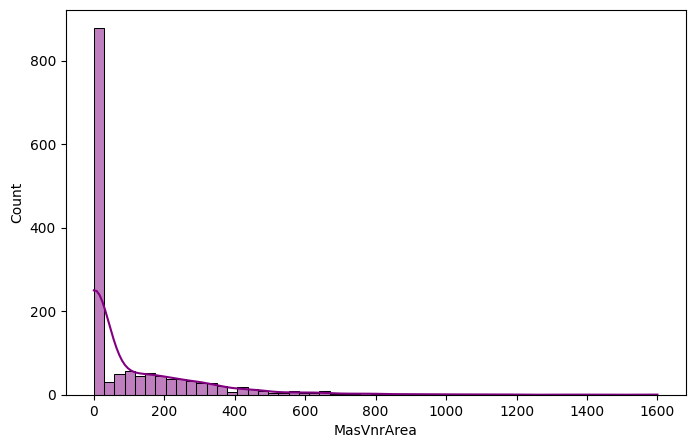

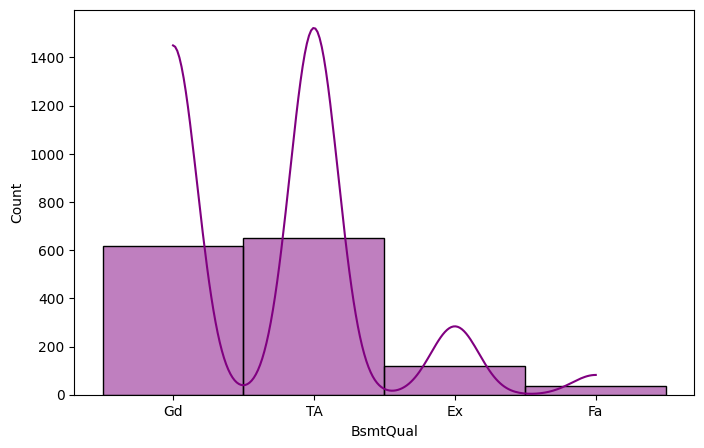

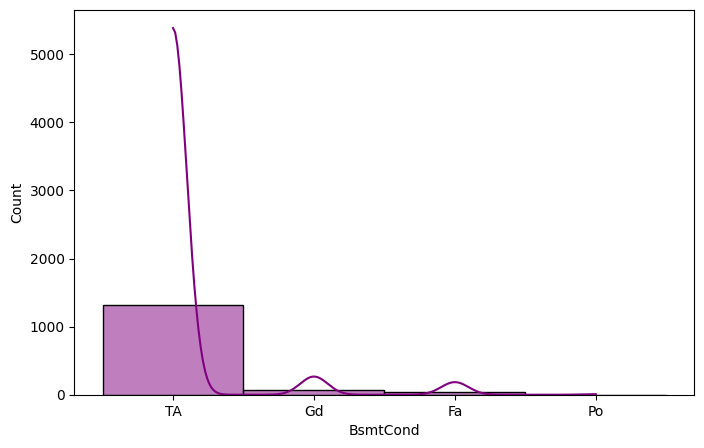

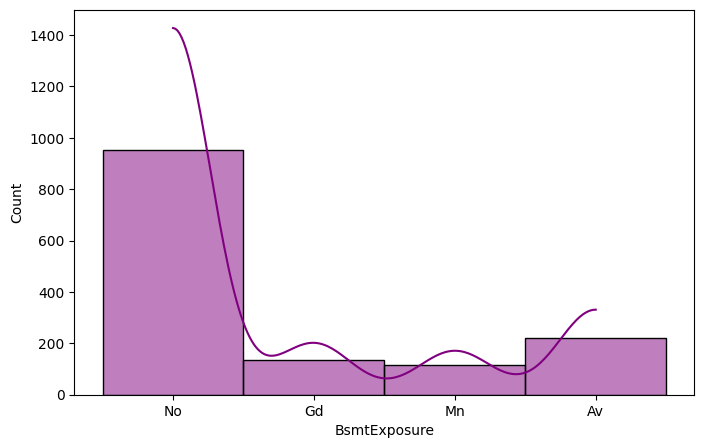

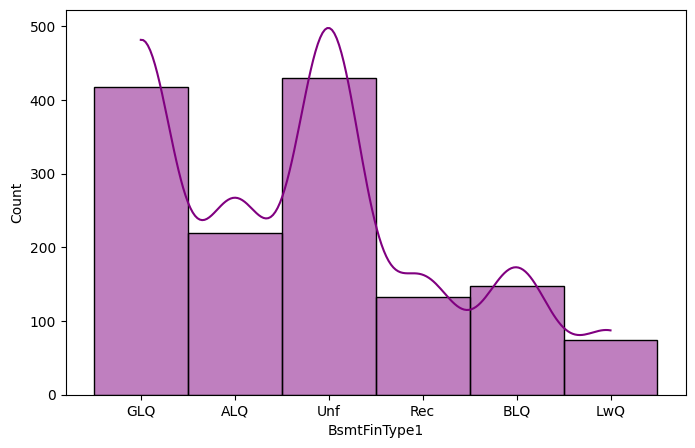

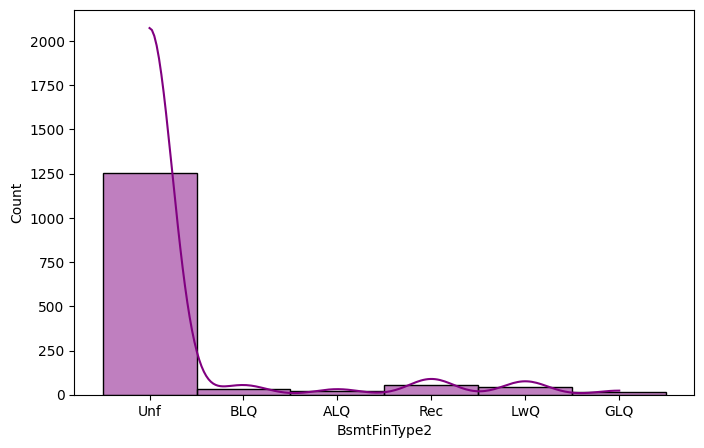

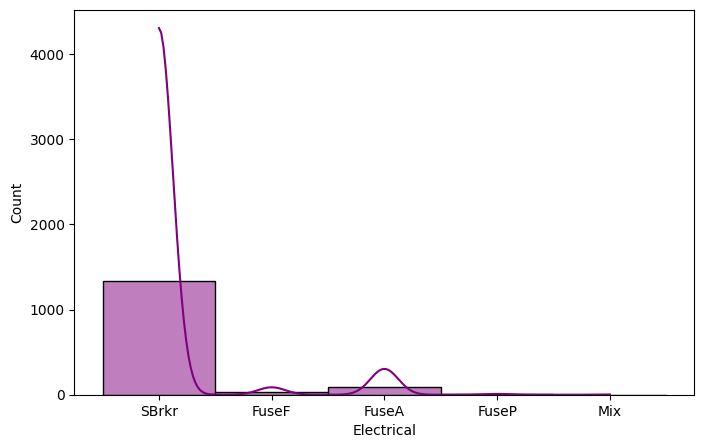

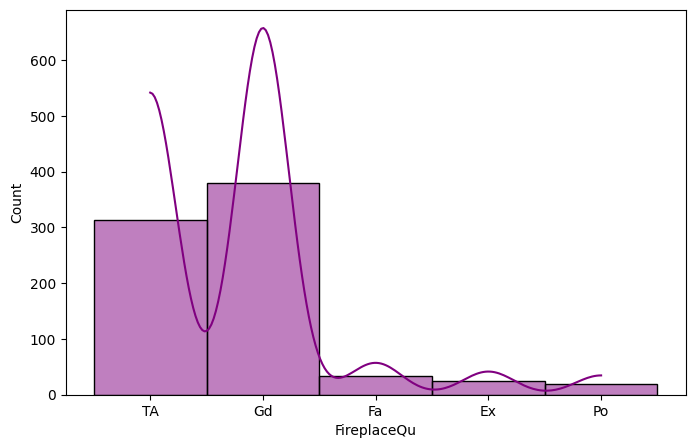

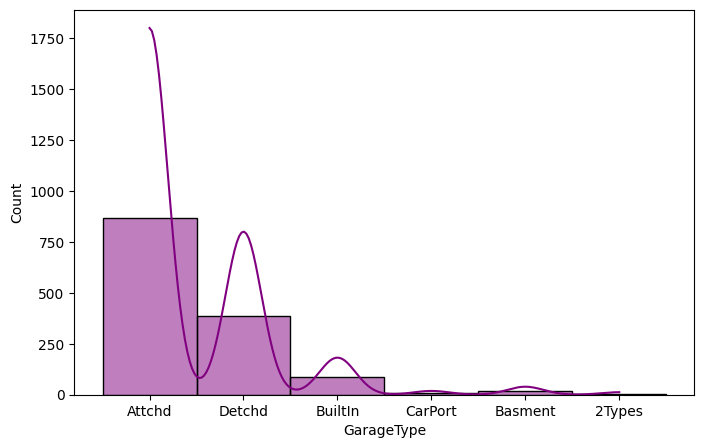

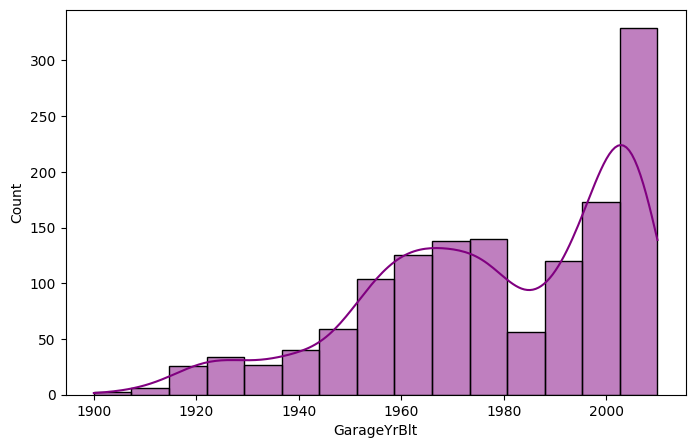

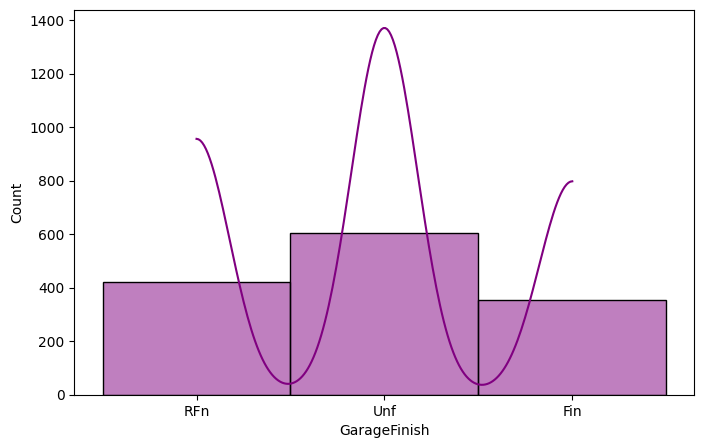

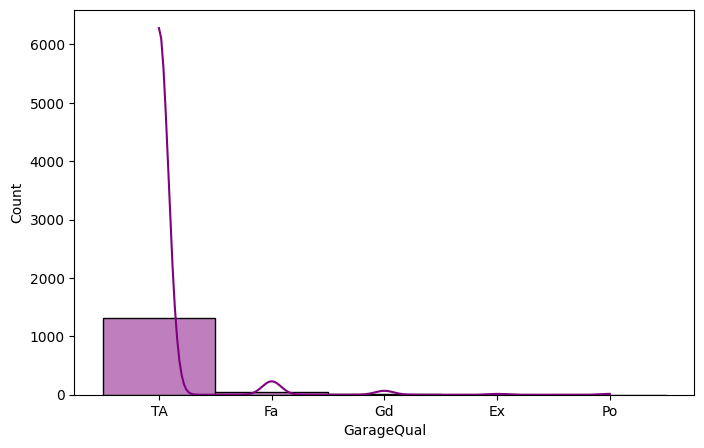

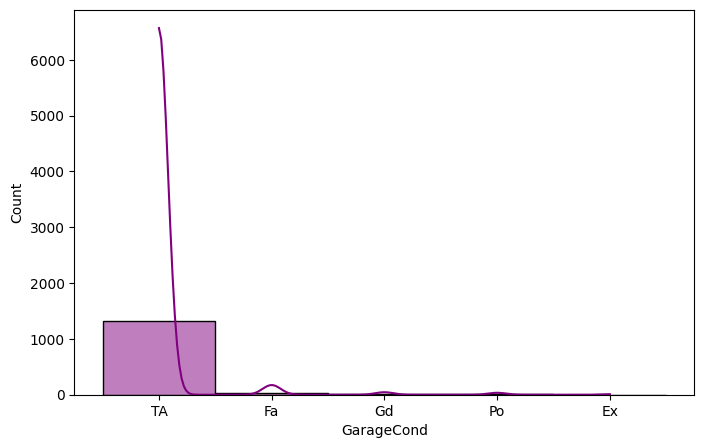

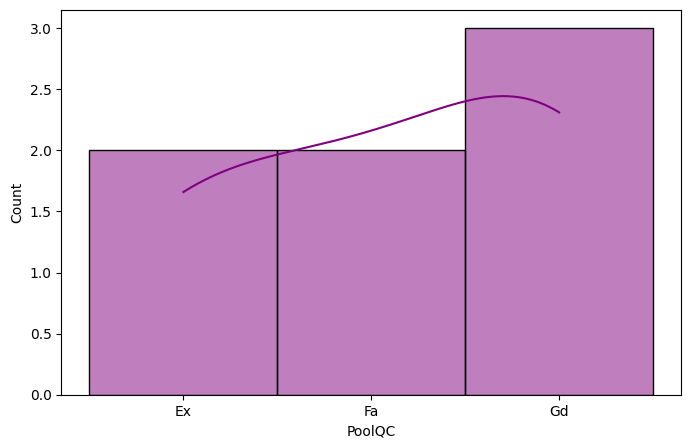

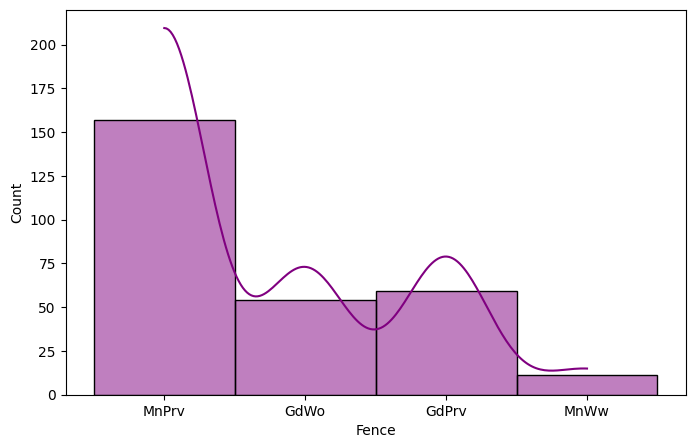

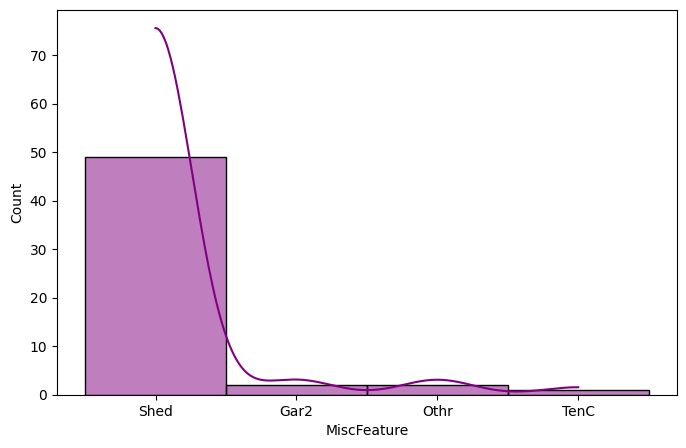

In [55]:
nan_col=['LotFrontage','Alley',
'MasVnrType',
'MasVnrArea','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
'Electrical',
'FireplaceQu',
'GarageType' ,
'GarageYrBlt' ,
'GarageFinish' ,
'GarageQual' ,
'GarageCond' ,
'PoolQC',
'Fence' ,
'MiscFeature']
for col in nan_col:
    plt.figure(figsize=(8,5))
    sns.histplot(x=col,data=X,kde=True,color='purple')
    plt.show()

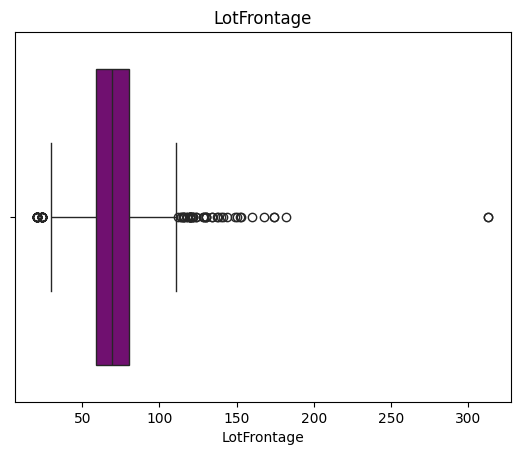

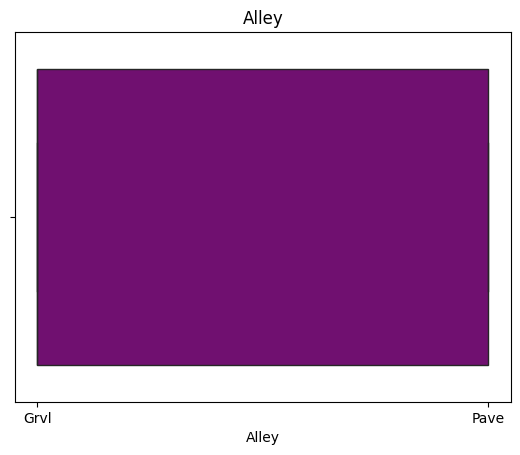

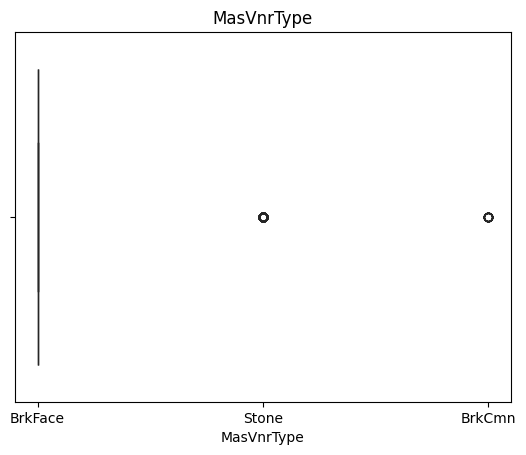

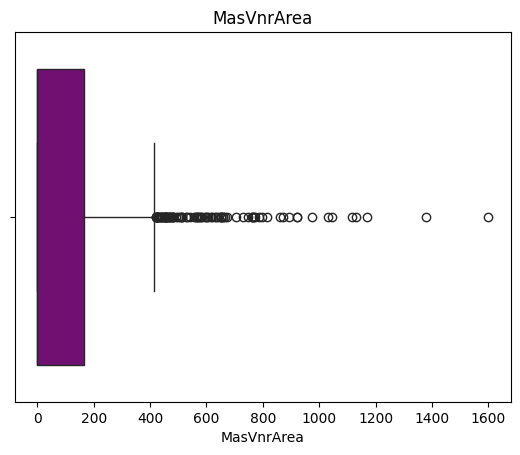

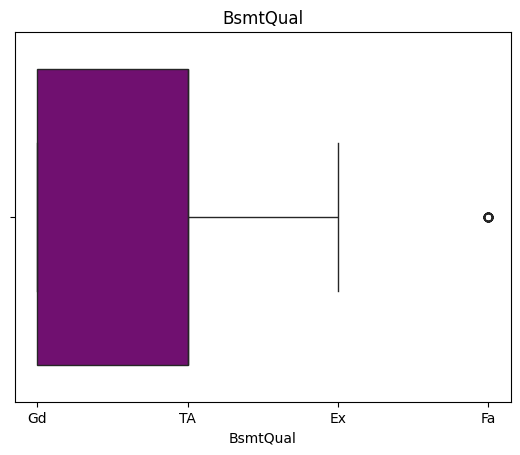

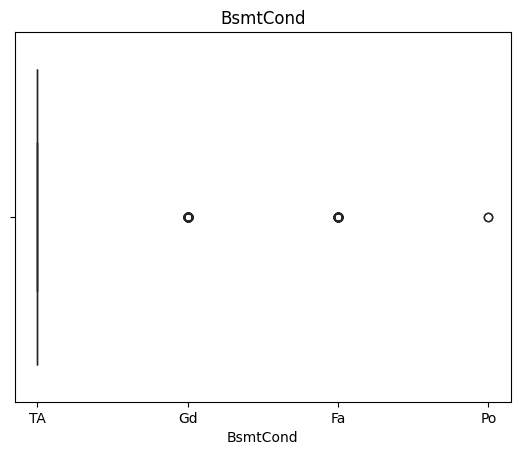

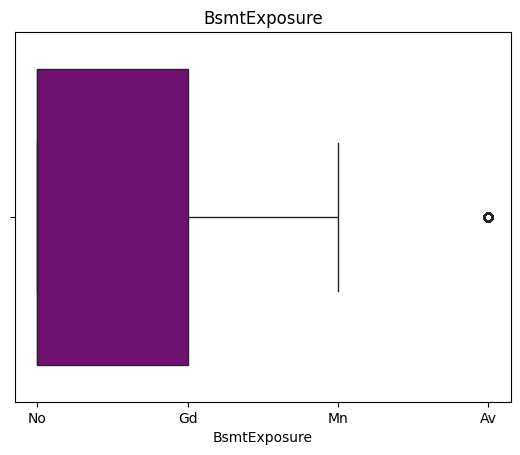

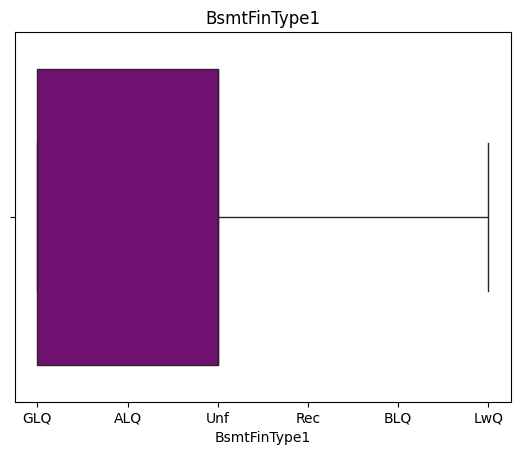

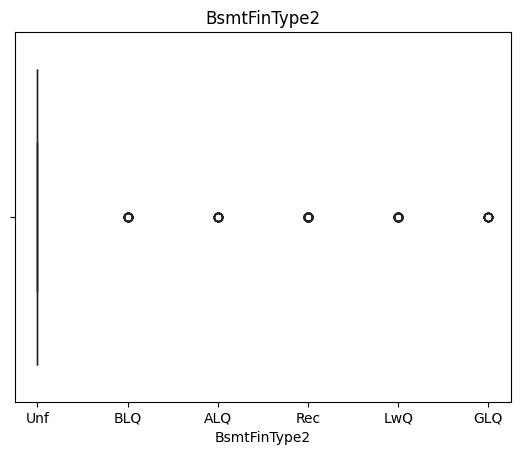

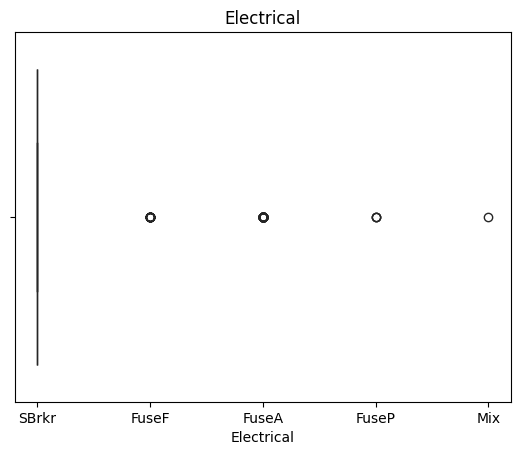

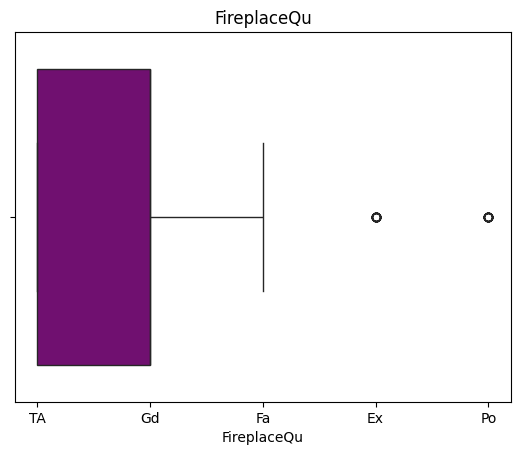

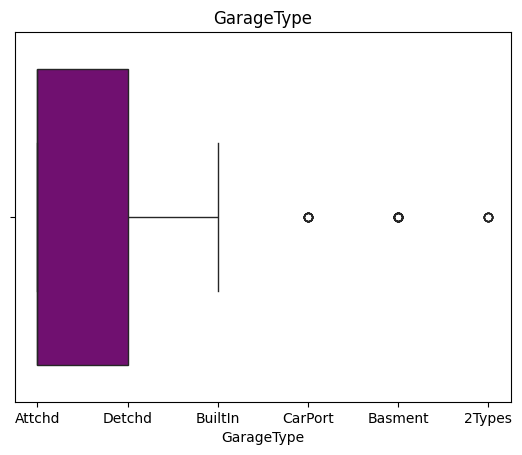

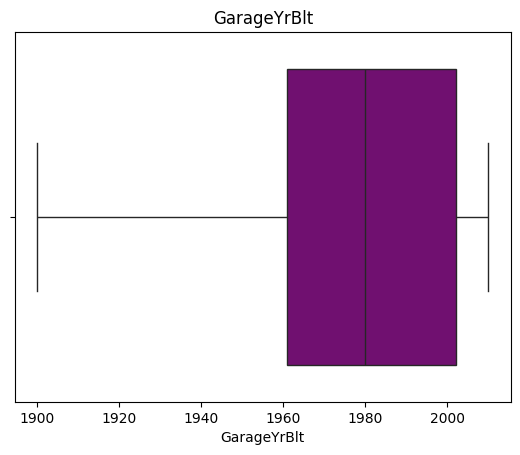

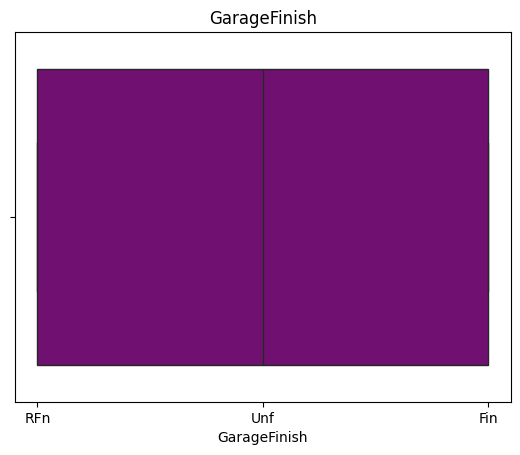

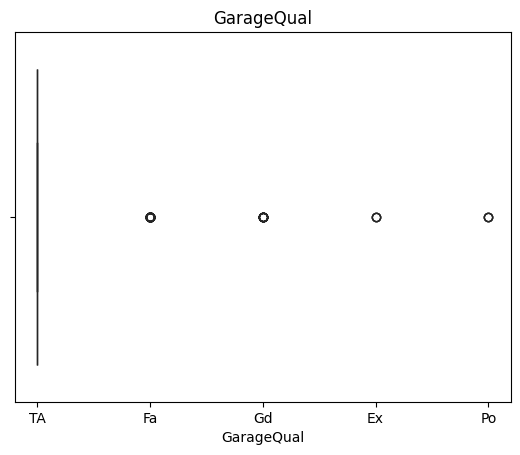

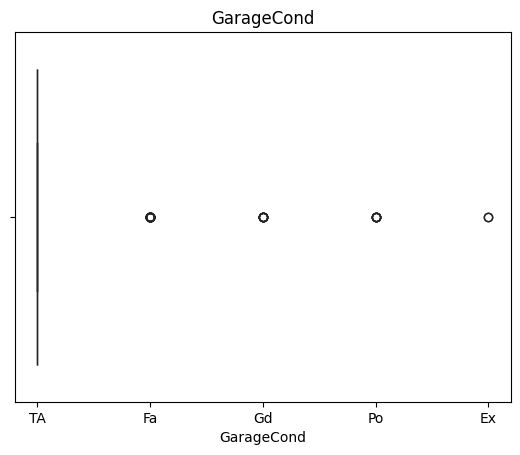

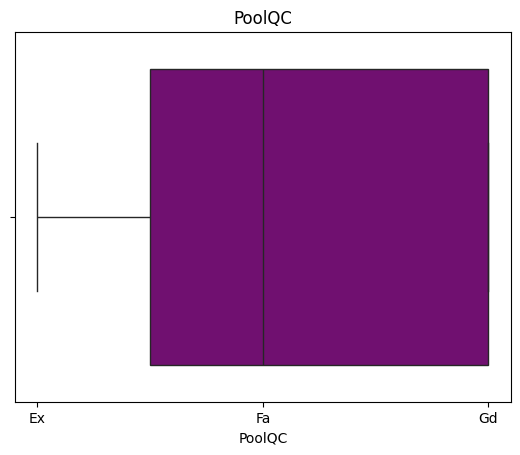

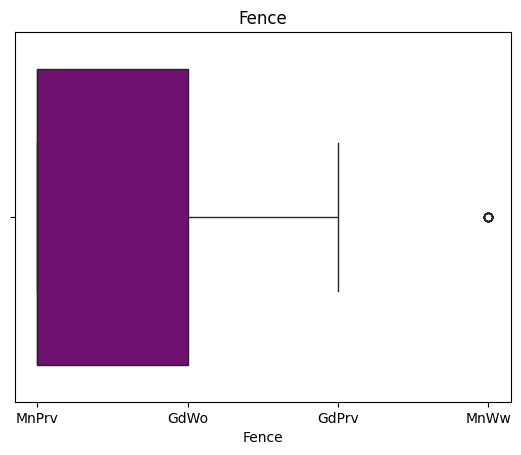

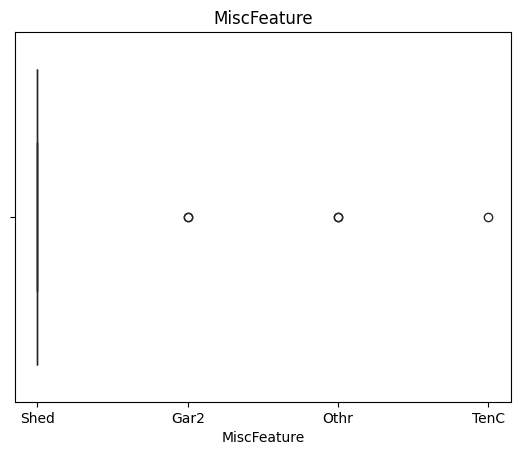

In [56]:
for col in nan_col:
    sns.boxplot(x=col,data=X,color='purple')
    plt.title(col)
    plt.show()

In [57]:
col_with_low_nan=[]
col_with_high_nan=[]

for col in nan_col:
    p=X[col].isnull().sum()
    q=X[col].value_counts().sum()
    if 100*p/(p+q)<10:
        col_with_low_nan.append(col)
    else:
        col_with_high_nan.append(col)
    print(col,"%nans : ",100*p/(p+q))

LotFrontage %nans :  17.73972602739726
Alley %nans :  93.76712328767124
MasVnrType %nans :  59.726027397260275
MasVnrArea %nans :  0.547945205479452
BsmtQual %nans :  2.5342465753424657
BsmtCond %nans :  2.5342465753424657
BsmtExposure %nans :  2.6027397260273974
BsmtFinType1 %nans :  2.5342465753424657
BsmtFinType2 %nans :  2.6027397260273974
Electrical %nans :  0.0684931506849315
FireplaceQu %nans :  47.26027397260274
GarageType %nans :  5.5479452054794525
GarageYrBlt %nans :  5.5479452054794525
GarageFinish %nans :  5.5479452054794525
GarageQual %nans :  5.5479452054794525
GarageCond %nans :  5.5479452054794525
PoolQC %nans :  99.52054794520548
Fence %nans :  80.75342465753425
MiscFeature %nans :  96.3013698630137


In [58]:
X.isnull().sum()*100/len(X)

MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
Street            0.000000
                   ...    
SaleType          0.000000
SaleCondition     0.000000
QualXCond         0.000000
Roof_qual         0.000000
Exterior          0.000000
Length: 76, dtype: float64

BsmtQual 37
BsmtCond 37
BsmtExposure 38
BsmtFinType1 37
BsmtFinType2 38
Electrical 1
FireplaceQu 690
GarageType 81
GarageYrBlt 81
GarageFinish 81
GarageQual 81
GarageCond 81
PoolQC 1453
Fence 1179
MiscFeature 1406

In [59]:
print(col_with_high_nan)
print(col_with_low_nan)

['LotFrontage', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
['MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']


In [60]:
median_cols = ['LotFrontage'] # measurement missing 
zero_cols = ['MasVnrArea', 'GarageYrBlt'] # No masonry veneer i.e area =0

# Features that does not exist/absent in house 
cat_none_cols = [
    'Alley','MasVnrType','BsmtQual','BsmtCond','BsmtExposure',
    'BsmtFinType1','BsmtFinType2','FireplaceQu','GarageType',
    'GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature'
]

mode_cols = ['Electrical']

# Filling the values 

In [61]:
df.sample(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1096,70,RM,60.0,6882,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,127000
854,20,RL,102.0,17920,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2006,WD,Abnorml,170000
585,20,RL,88.0,11443,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,3,2006,New,Partial,369900
1164,80,RL,NaN,16157,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,194000
499,20,RL,70.0,7535,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnWw,Shed,480,6,2007,WD,Normal,120000


In [62]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder

In [63]:
preprocessor = ColumnTransformer(
    transformers=[
        ('median', SimpleImputer(strategy='median'), median_cols),
        ('zero', SimpleImputer(strategy='constant', fill_value=0), zero_cols),
        ('none', SimpleImputer(strategy='constant', fill_value='None'), cat_none_cols),
        ('mode', SimpleImputer(strategy='most_frequent'), mode_cols),
    ],
    remainder='passthrough' ,
    verbose_feature_names_out=False # To preserve the original column's name 
)
pipe = Pipeline(steps=[('preprocessor', preprocessor)])

In [64]:
X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual,Exterior
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,0,2,2008,WD,Normal,35,2.592,4.00
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,NaN,NaN,0,5,2007,WD,Normal,48,2.592,1.93
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,0,9,2008,WD,Normal,35,2.592,4.00
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,0,2,2006,WD,Abnorml,35,2.592,1.92
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,NaN,NaN,0,12,2008,WD,Normal,40,2.592,4.00


In [65]:
pipe.set_output(transform='pandas')
X_cleaned=pipe.fit_transform(X)

In [66]:
X_cleaned.head(10)

,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,...,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual,Exterior
0,65.0,196.0,2003.0,None,BrkFace,Gd,TA,No,GLQ,Unf,...,0,0,0,2,2008,WD,Normal,35,2.592,4.00
1,80.0,0.0,1976.0,None,None,Gd,TA,Gd,ALQ,Unf,...,0,0,0,5,2007,WD,Normal,48,2.592,1.93
2,68.0,162.0,2001.0,None,BrkFace,Gd,TA,Mn,GLQ,Unf,...,0,0,0,9,2008,WD,Normal,35,2.592,4.00
3,60.0,0.0,1998.0,None,None,TA,Gd,No,ALQ,Unf,...,0,0,0,2,2006,WD,Abnorml,35,2.592,1.92
4,84.0,350.0,2000.0,None,BrkFace,Gd,TA,Av,GLQ,Unf,...,0,0,0,12,2008,WD,Normal,40,2.592,4.00
5,85.0,0.0,1993.0,None,None,Gd,TA,No,GLQ,Unf,...,0,0,700,10,2009,WD,Normal,25,2.592,4.00
6,75.0,186.0,2004.0,None,Stone,Ex,TA,Av,GLQ,Unf,...,0,0,0,8,2007,WD,Normal,40,2.592,4.00
7,69.0,240.0,1973.0,None,Stone,Gd,TA,Mn,ALQ,BLQ,...,0,0,350,11,2009,WD,Normal,42,2.592,2.32
8,51.0,0.0,1931.0,None,None,TA,TA,No,Unf,Unf,...,0,0,0,4,2008,WD,Abnorml,35,2.592,2.29
9,50.0,0.0,1939.0,None,None,TA,TA,No,GLQ,Unf,...,0,0,0,1,2008,WD,Normal,30,2.592,1.93


In [67]:
X_cleaned.isnull().sum()

LotFrontage      0
MasVnrArea       0
GarageYrBlt      0
Alley            0
MasVnrType       0
                ..
SaleType         0
SaleCondition    0
QualXCond        0
Roof_qual        0
Exterior         0
Length: 76, dtype: int64

In [68]:
X_cleaned.columns

Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'Alley', 'MasVnrType',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PoolQC', 'Fence', 'MiscFeature', 'Electrical', 'MSSubClass',
       'MSZoning', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'YearBuilt', 'YearRemodAdd', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageCars', 'GarageArea',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
  

In [69]:
X_cleaned.columns[X_cleaned.dtypes==object]

Index(['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature', 'Electrical', 'MSZoning', 'Street', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'ExterQual',
       'ExterCond', 'Foundation', 'Heating', 'HeatingQC', 'CentralAir',
       'KitchenQual', 'Functional', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [70]:
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'LotShape', 'LandSlope', 'Utilities', 'Functional', 'Fence']
nominal_cols = ['MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'Foundation', 'GarageType', 'MiscFeature', 'Electrical', 'Heating', 'CentralAir', 'PavedDrive', 'MasVnrType', 'SaleType', 'SaleCondition']

In [71]:
qual_scale = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
ordinal_transformer = OrdinalEncoder(categories=[qual_scale] * len(qual_cols))


In [72]:
ohe=OneHotEncoder()

In [73]:
X_cleaned.head()

,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,...,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual,Exterior
0,65.0,196.0,2003.0,None,BrkFace,Gd,TA,No,GLQ,Unf,...,0,0,0,2,2008,WD,Normal,35,2.592,4.00
1,80.0,0.0,1976.0,None,None,Gd,TA,Gd,ALQ,Unf,...,0,0,0,5,2007,WD,Normal,48,2.592,1.93
2,68.0,162.0,2001.0,None,BrkFace,Gd,TA,Mn,GLQ,Unf,...,0,0,0,9,2008,WD,Normal,35,2.592,4.00
3,60.0,0.0,1998.0,None,None,TA,Gd,No,ALQ,Unf,...,0,0,0,2,2006,WD,Abnorml,35,2.592,1.92
4,84.0,350.0,2000.0,None,BrkFace,Gd,TA,Av,GLQ,Unf,...,0,0,0,12,2008,WD,Normal,40,2.592,4.00


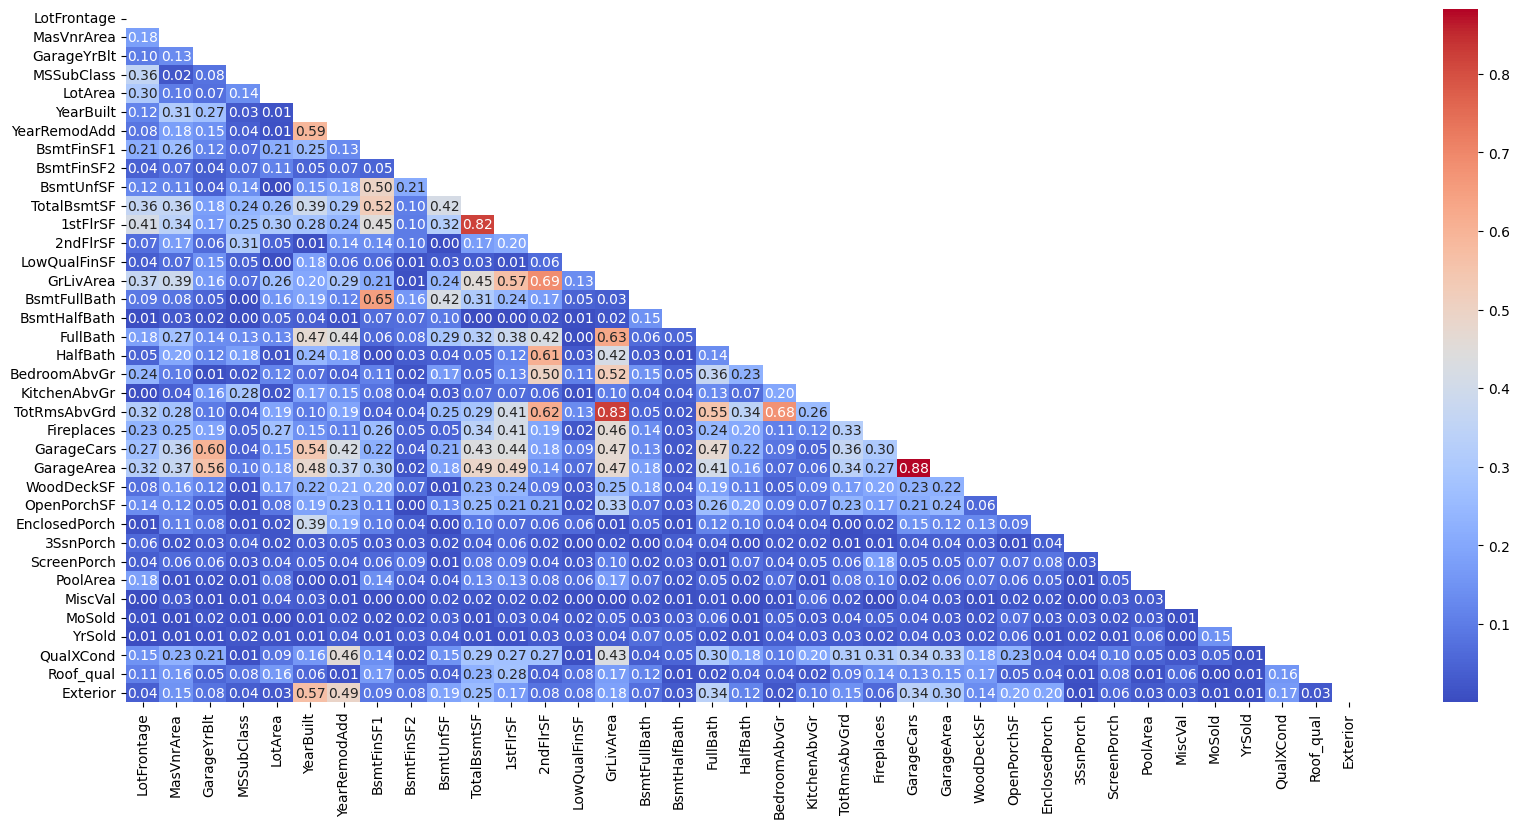

In [74]:
plt.figure(figsize=(20,9))
corr=X_cleaned.corr(numeric_only=True).abs()
sns.heatmap(corr,annot =True,cmap='coolwarm',mask=np.triu(np.ones_like(corr, dtype=bool),k=0),fmt='.2f')
plt.show()

## Columns with high correlation 

In [75]:
tri_X=corr.where(np.triu(np.ones_like(corr,dtype=bool),k=1))
threshold=0.7
high_corr=tri_X.stack().reset_index()
high_corr.columns=['feature 1','feature 2','correlation']
pair=high_corr[high_corr['correlation']>threshold]
pair

,feature 1,feature 2,correlation
315,TotalBsmtSF,1stFlrSF,0.819530
419,GrLivArea,TotRmsAbvGrd,0.825489
575,GarageCars,GarageArea,0.882475


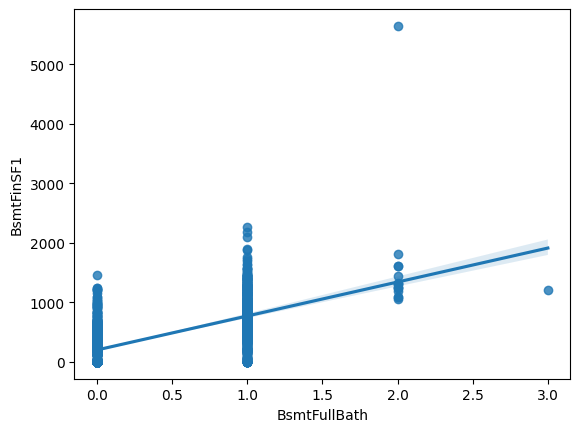

In [76]:
# Regplot (Scatter + Trend Line)
sns.regplot(y='BsmtFinSF1',x='BsmtFullBath',data=X_cleaned)
plt.show()

In [77]:
X_cleaned.loc[X_cleaned['GarageCars']==0 ,'GarageArea']

39      0
48      0
78      0
88      0
89      0
       ..
1349    0
1407    0
1449    0
1450    0
1453    0
Name: GarageArea, Length: 81, dtype: int64

In [78]:
X['GarageArea']

0       548
1       460
2       608
3       642
4       836
       ... 
1455    460
1456    500
1457    252
1458    240
1459    276
Name: GarageArea, Length: 1460, dtype: int64

In [79]:
garagemax=X_cleaned['GarageArea'].max()
garagemax  

1418

In [80]:
X_cleaned['areaBycar'] = X_cleaned.apply(
    lambda row: garagemax if row['GarageCars'] == 0 
    else round(row['GarageArea'] / row['GarageCars'],2), 
    axis=1
)
X_cleaned.drop(columns={'GarageCars','GarageArea'},axis=1,inplace=True)
X_cleaned.head()

,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,...,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual,Exterior,areaBycar
0,65.0,196.0,2003.0,None,BrkFace,Gd,TA,No,GLQ,Unf,...,0,0,2,2008,WD,Normal,35,2.592,4.00,274.00
1,80.0,0.0,1976.0,None,None,Gd,TA,Gd,ALQ,Unf,...,0,0,5,2007,WD,Normal,48,2.592,1.93,230.00
2,68.0,162.0,2001.0,None,BrkFace,Gd,TA,Mn,GLQ,Unf,...,0,0,9,2008,WD,Normal,35,2.592,4.00,304.00
3,60.0,0.0,1998.0,None,None,TA,Gd,No,ALQ,Unf,...,0,0,2,2006,WD,Abnorml,35,2.592,1.92,214.00
4,84.0,350.0,2000.0,None,BrkFace,Gd,TA,Av,GLQ,Unf,...,0,0,12,2008,WD,Normal,40,2.592,4.00,278.67


In [81]:
X_cleaned['areaBycar'].isnull().sum()

0

In [82]:
X_cleaned['areaBycar']=X_cleaned['areaBycar'].round(2)

In [83]:
X_cleaned.head()

,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,...,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual,Exterior,areaBycar
0,65.0,196.0,2003.0,None,BrkFace,Gd,TA,No,GLQ,Unf,...,0,0,2,2008,WD,Normal,35,2.592,4.00,274.00
1,80.0,0.0,1976.0,None,None,Gd,TA,Gd,ALQ,Unf,...,0,0,5,2007,WD,Normal,48,2.592,1.93,230.00
2,68.0,162.0,2001.0,None,BrkFace,Gd,TA,Mn,GLQ,Unf,...,0,0,9,2008,WD,Normal,35,2.592,4.00,304.00
3,60.0,0.0,1998.0,None,None,TA,Gd,No,ALQ,Unf,...,0,0,2,2006,WD,Abnorml,35,2.592,1.92,214.00
4,84.0,350.0,2000.0,None,BrkFace,Gd,TA,Av,GLQ,Unf,...,0,0,12,2008,WD,Normal,40,2.592,4.00,278.67


In [84]:
# X_cleaned.plot.hexbin(x="BsmtFinSF1",y='BsmtFullBath',gridsize=500)  # good for large row size 

In [85]:
len(X_cleaned.columns)

75

In [86]:
X_cleaned['Avg_Room_Size'] = X_cleaned['GrLivArea'] / X_cleaned['TotRmsAbvGrd']
X_cleaned.drop(columns={'GrLivArea','TotRmsAbvGrd'},axis=1,inplace=True)
X_cleaned.head()

,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual,Exterior,areaBycar,Avg_Room_Size
0,65.0,196.0,2003.0,None,BrkFace,Gd,TA,No,GLQ,Unf,...,0,2,2008,WD,Normal,35,2.592,4.00,274.00,213.750000
1,80.0,0.0,1976.0,None,None,Gd,TA,Gd,ALQ,Unf,...,0,5,2007,WD,Normal,48,2.592,1.93,230.00,210.333333
2,68.0,162.0,2001.0,None,BrkFace,Gd,TA,Mn,GLQ,Unf,...,0,9,2008,WD,Normal,35,2.592,4.00,304.00,297.666667
3,60.0,0.0,1998.0,None,None,TA,Gd,No,ALQ,Unf,...,0,2,2006,WD,Abnorml,35,2.592,1.92,214.00,245.285714
4,84.0,350.0,2000.0,None,BrkFace,Gd,TA,Av,GLQ,Unf,...,0,12,2008,WD,Normal,40,2.592,4.00,278.67,244.222222


In [87]:
X_cleaned['Avg_Room_Size']=X_cleaned['Avg_Room_Size'].round(2)

In [88]:
X_cleaned.head()

,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual,Exterior,areaBycar,Avg_Room_Size
0,65.0,196.0,2003.0,None,BrkFace,Gd,TA,No,GLQ,Unf,...,0,2,2008,WD,Normal,35,2.592,4.00,274.00,213.75
1,80.0,0.0,1976.0,None,None,Gd,TA,Gd,ALQ,Unf,...,0,5,2007,WD,Normal,48,2.592,1.93,230.00,210.33
2,68.0,162.0,2001.0,None,BrkFace,Gd,TA,Mn,GLQ,Unf,...,0,9,2008,WD,Normal,35,2.592,4.00,304.00,297.67
3,60.0,0.0,1998.0,None,None,TA,Gd,No,ALQ,Unf,...,0,2,2006,WD,Abnorml,35,2.592,1.92,214.00,245.29
4,84.0,350.0,2000.0,None,BrkFace,Gd,TA,Av,GLQ,Unf,...,0,12,2008,WD,Normal,40,2.592,4.00,278.67,244.22


In [89]:
X_cleaned['Total_House_SF'] = X_cleaned['TotalBsmtSF'] + X_cleaned['1stFlrSF'] + X_cleaned['2ndFlrSF']
X_cleaned.drop(columns={'TotalBsmtSF','1stFlrSF','2ndFlrSF'},axis=1,inplace=True)
X_cleaned['Total_House_SF']=X_cleaned['Total_House_SF'].round(2)
X_cleaned.head()

,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,...,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual,Exterior,areaBycar,Avg_Room_Size,Total_House_SF
0,65.0,196.0,2003.0,None,BrkFace,Gd,TA,No,GLQ,Unf,...,2,2008,WD,Normal,35,2.592,4.00,274.00,213.75,2566
1,80.0,0.0,1976.0,None,None,Gd,TA,Gd,ALQ,Unf,...,5,2007,WD,Normal,48,2.592,1.93,230.00,210.33,2524
2,68.0,162.0,2001.0,None,BrkFace,Gd,TA,Mn,GLQ,Unf,...,9,2008,WD,Normal,35,2.592,4.00,304.00,297.67,2706
3,60.0,0.0,1998.0,None,None,TA,Gd,No,ALQ,Unf,...,2,2006,WD,Abnorml,35,2.592,1.92,214.00,245.29,2473
4,84.0,350.0,2000.0,None,BrkFace,Gd,TA,Av,GLQ,Unf,...,12,2008,WD,Normal,40,2.592,4.00,278.67,244.22,3343


In [90]:
len(X_cleaned.columns)

72

In [91]:
X_cleaned.sample(10)

,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,...,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual,Exterior,areaBycar,Avg_Room_Size,Total_House_SF
582,81.0,104.0,0.0,None,BrkFace,Gd,TA,Av,GLQ,Unf,...,5,2007,WD,Normal,30,2.5920,2.32,1418.00,163.20,1632
29,60.0,0.0,1920.0,None,None,TA,TA,No,Unf,Unf,...,5,2008,WD,Normal,24,2.5920,1.93,240.00,130.00,1040
942,42.0,0.0,0.0,None,None,Gd,TA,Gd,GLQ,Unf,...,8,2007,Oth,Abnorml,12,2.5920,1.93,1418.00,180.00,2880
1172,35.0,0.0,2006.0,Pave,None,Gd,TA,No,Unf,Unf,...,3,2008,WD,Normal,35,2.5920,1.93,312.50,250.00,1875
1393,60.0,0.0,2003.0,Pave,None,Fa,TA,No,Unf,Unf,...,4,2008,WD,Normal,42,2.5920,1.92,336.00,273.14,2394
21,57.0,0.0,1930.0,Grvl,None,TA,TA,No,Unf,Unf,...,6,2007,WD,Normal,49,2.5920,1.92,280.00,184.67,1745
926,93.0,340.0,2003.0,None,BrkFace,Gd,TA,No,Unf,Unf,...,5,2007,WD,Normal,40,2.8593,4.00,218.67,237.40,3555
783,69.0,104.0,1978.0,None,BrkFace,Gd,TA,Av,GLQ,Unf,...,7,2009,WD,Normal,30,2.5920,2.69,301.00,277.50,2207
431,60.0,0.0,0.0,None,None,TA,TA,No,Unf,Unf,...,9,2008,ConLD,Abnorml,42,2.5920,1.93,1418.00,171.14,2099
940,55.0,0.0,1976.0,None,None,TA,TA,Gd,Rec,LwQ,...,7,2006,WD,Normal,30,2.5920,2.69,287.00,216.00,3456


In [92]:
X_cleaned['PoolQC'].unique()

array(['None', 'Ex', 'Fa', 'Gd'], dtype=object)

In [93]:
qual_map = {
    'Ex': 5, 
    'Gd': 4, 
    'TA': 3, 
    'Fa': 2, 
    'Po': 1, 
    'None': 0
}

# (Check your dataset, but these are the usual suspects)
ord_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
            'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond','PoolQC']

# 3. Apply the mapping
for col in ord_cols:
    if col in X_cleaned.columns:
        X_cleaned[col] = X_cleaned[col].map(qual_map)


In [94]:
X_cleaned.select_dtypes(include=['object'])

,Alley,MasVnrType,BsmtExposure,BsmtFinType1,BsmtFinType2,GarageType,GarageFinish,Fence,MiscFeature,Electrical,...,Condition2,BldgType,HouseStyle,Foundation,Heating,CentralAir,Functional,PavedDrive,SaleType,SaleCondition
0,None,BrkFace,No,GLQ,Unf,Attchd,RFn,None,None,SBrkr,...,Norm,1Fam,2Story,PConc,GasA,Y,Typ,Y,WD,Normal
1,None,None,Gd,ALQ,Unf,Attchd,RFn,None,None,SBrkr,...,Norm,1Fam,1Story,CBlock,GasA,Y,Typ,Y,WD,Normal
2,None,BrkFace,Mn,GLQ,Unf,Attchd,RFn,None,None,SBrkr,...,Norm,1Fam,2Story,PConc,GasA,Y,Typ,Y,WD,Normal
3,None,None,No,ALQ,Unf,Detchd,Unf,None,None,SBrkr,...,Norm,1Fam,2Story,BrkTil,GasA,Y,Typ,Y,WD,Abnorml
4,None,BrkFace,Av,GLQ,Unf,Attchd,RFn,None,None,SBrkr,...,Norm,1Fam,2Story,PConc,GasA,Y,Typ,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,None,None,No,Unf,Unf,Attchd,RFn,None,None,SBrkr,...,Norm,1Fam,2Story,PConc,GasA,Y,Typ,Y,WD,Normal
1456,None,Stone,No,ALQ,Rec,Attchd,Unf,MnPrv,None,SBrkr,...,Norm,1Fam,1Story,CBlock,GasA,Y,Min1,Y,WD,Normal
1457,None,None,No,GLQ,Unf,Attchd,RFn,GdPrv,Shed,SBrkr,...,Norm,1Fam,2Story,Stone,GasA,Y,Typ,Y,WD,Normal
1458,None,None,Mn,GLQ,Rec,Attchd,Unf,None,None,FuseA,...,Norm,1Fam,1Story,CBlock,GasA,Y,Typ,Y,WD,Normal


In [95]:
X_cleaned['PavedDrive'].unique()

array(['Y', 'N', 'P'], dtype=object)

In [96]:
X_cleaned['PavedDrive']= X_cleaned['PavedDrive'].map({
    'Y':2,
    'N':1,
    'P':0
})
X_cleaned['PavedDrive'].unique()

array([2, 1, 0], dtype=int64)

In [97]:
X_cleaned.head()

,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,...,MoSold,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual,Exterior,areaBycar,Avg_Room_Size,Total_House_SF
0,65.0,196.0,2003.0,None,BrkFace,4,3,No,GLQ,Unf,...,2,2008,WD,Normal,35,2.592,4.00,274.00,213.75,2566
1,80.0,0.0,1976.0,None,None,4,3,Gd,ALQ,Unf,...,5,2007,WD,Normal,48,2.592,1.93,230.00,210.33,2524
2,68.0,162.0,2001.0,None,BrkFace,4,3,Mn,GLQ,Unf,...,9,2008,WD,Normal,35,2.592,4.00,304.00,297.67,2706
3,60.0,0.0,1998.0,None,None,3,4,No,ALQ,Unf,...,2,2006,WD,Abnorml,35,2.592,1.92,214.00,245.29,2473
4,84.0,350.0,2000.0,None,BrkFace,4,3,Av,GLQ,Unf,...,12,2008,WD,Normal,40,2.592,4.00,278.67,244.22,3343


In [98]:
X_cleaned['BsmtQualXCond']=X_cleaned['BsmtQual']*X_cleaned['BsmtCond']
X_cleaned.drop(columns={'BsmtCond','BsmtQual'},axis=1,inplace=True)
X_cleaned.head()

,LotFrontage,MasVnrArea,GarageYrBlt,Alley,MasVnrType,BsmtExposure,BsmtFinType1,BsmtFinType2,FireplaceQu,GarageType,...,YrSold,SaleType,SaleCondition,QualXCond,Roof_qual,Exterior,areaBycar,Avg_Room_Size,Total_House_SF,BsmtQualXCond
0,65.0,196.0,2003.0,None,BrkFace,No,GLQ,Unf,0,Attchd,...,2008,WD,Normal,35,2.592,4.00,274.00,213.75,2566,12
1,80.0,0.0,1976.0,None,None,Gd,ALQ,Unf,3,Attchd,...,2007,WD,Normal,48,2.592,1.93,230.00,210.33,2524,12
2,68.0,162.0,2001.0,None,BrkFace,Mn,GLQ,Unf,3,Attchd,...,2008,WD,Normal,35,2.592,4.00,304.00,297.67,2706,12
3,60.0,0.0,1998.0,None,None,No,ALQ,Unf,4,Detchd,...,2006,WD,Abnorml,35,2.592,1.92,214.00,245.29,2473,12
4,84.0,350.0,2000.0,None,BrkFace,Av,GLQ,Unf,3,Attchd,...,2008,WD,Normal,40,2.592,4.00,278.67,244.22,3343,12


In [99]:
X_cleaned.select_dtypes(include=['object'])

,Alley,MasVnrType,BsmtExposure,BsmtFinType1,BsmtFinType2,GarageType,GarageFinish,Fence,MiscFeature,Electrical,...,Condition1,Condition2,BldgType,HouseStyle,Foundation,Heating,CentralAir,Functional,SaleType,SaleCondition
0,None,BrkFace,No,GLQ,Unf,Attchd,RFn,None,None,SBrkr,...,Norm,Norm,1Fam,2Story,PConc,GasA,Y,Typ,WD,Normal
1,None,None,Gd,ALQ,Unf,Attchd,RFn,None,None,SBrkr,...,Feedr,Norm,1Fam,1Story,CBlock,GasA,Y,Typ,WD,Normal
2,None,BrkFace,Mn,GLQ,Unf,Attchd,RFn,None,None,SBrkr,...,Norm,Norm,1Fam,2Story,PConc,GasA,Y,Typ,WD,Normal
3,None,None,No,ALQ,Unf,Detchd,Unf,None,None,SBrkr,...,Norm,Norm,1Fam,2Story,BrkTil,GasA,Y,Typ,WD,Abnorml
4,None,BrkFace,Av,GLQ,Unf,Attchd,RFn,None,None,SBrkr,...,Norm,Norm,1Fam,2Story,PConc,GasA,Y,Typ,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,None,None,No,Unf,Unf,Attchd,RFn,None,None,SBrkr,...,Norm,Norm,1Fam,2Story,PConc,GasA,Y,Typ,WD,Normal
1456,None,Stone,No,ALQ,Rec,Attchd,Unf,MnPrv,None,SBrkr,...,Norm,Norm,1Fam,1Story,CBlock,GasA,Y,Min1,WD,Normal
1457,None,None,No,GLQ,Unf,Attchd,RFn,GdPrv,Shed,SBrkr,...,Norm,Norm,1Fam,2Story,Stone,GasA,Y,Typ,WD,Normal
1458,None,None,Mn,GLQ,Rec,Attchd,Unf,None,None,FuseA,...,Norm,Norm,1Fam,1Story,CBlock,GasA,Y,Typ,WD,Normal


In [100]:
X_cleaned['CentralAir']=X_cleaned['CentralAir'].map({
    'Y':1,
    'N':0
})

In [101]:
X_cleaned.select_dtypes(include=['object'])

,Alley,MasVnrType,BsmtExposure,BsmtFinType1,BsmtFinType2,GarageType,GarageFinish,Fence,MiscFeature,Electrical,...,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,Foundation,Heating,Functional,SaleType,SaleCondition
0,None,BrkFace,No,GLQ,Unf,Attchd,RFn,None,None,SBrkr,...,CollgCr,Norm,Norm,1Fam,2Story,PConc,GasA,Typ,WD,Normal
1,None,None,Gd,ALQ,Unf,Attchd,RFn,None,None,SBrkr,...,Veenker,Feedr,Norm,1Fam,1Story,CBlock,GasA,Typ,WD,Normal
2,None,BrkFace,Mn,GLQ,Unf,Attchd,RFn,None,None,SBrkr,...,CollgCr,Norm,Norm,1Fam,2Story,PConc,GasA,Typ,WD,Normal
3,None,None,No,ALQ,Unf,Detchd,Unf,None,None,SBrkr,...,Crawfor,Norm,Norm,1Fam,2Story,BrkTil,GasA,Typ,WD,Abnorml
4,None,BrkFace,Av,GLQ,Unf,Attchd,RFn,None,None,SBrkr,...,NoRidge,Norm,Norm,1Fam,2Story,PConc,GasA,Typ,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,None,None,No,Unf,Unf,Attchd,RFn,None,None,SBrkr,...,Gilbert,Norm,Norm,1Fam,2Story,PConc,GasA,Typ,WD,Normal
1456,None,Stone,No,ALQ,Rec,Attchd,Unf,MnPrv,None,SBrkr,...,NWAmes,Norm,Norm,1Fam,1Story,CBlock,GasA,Min1,WD,Normal
1457,None,None,No,GLQ,Unf,Attchd,RFn,GdPrv,Shed,SBrkr,...,Crawfor,Norm,Norm,1Fam,2Story,Stone,GasA,Typ,WD,Normal
1458,None,None,Mn,GLQ,Rec,Attchd,Unf,None,None,FuseA,...,NAmes,Norm,Norm,1Fam,1Story,CBlock,GasA,Typ,WD,Normal


In [102]:
print(X_cleaned['Condition1'].unique())
X_cleaned['Condition2'].unique()

['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']


array(['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'PosA', 'RRAn', 'RRAe'],
      dtype=object)

In [103]:
Nominal_col=['MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig', 
                'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 
                'HouseStyle',  'Exterior', 'MasVnrType', 'Foundation', 'Heating', 
                'CentralAir', 'GarageType', 'SaleType', 'SaleCondition']

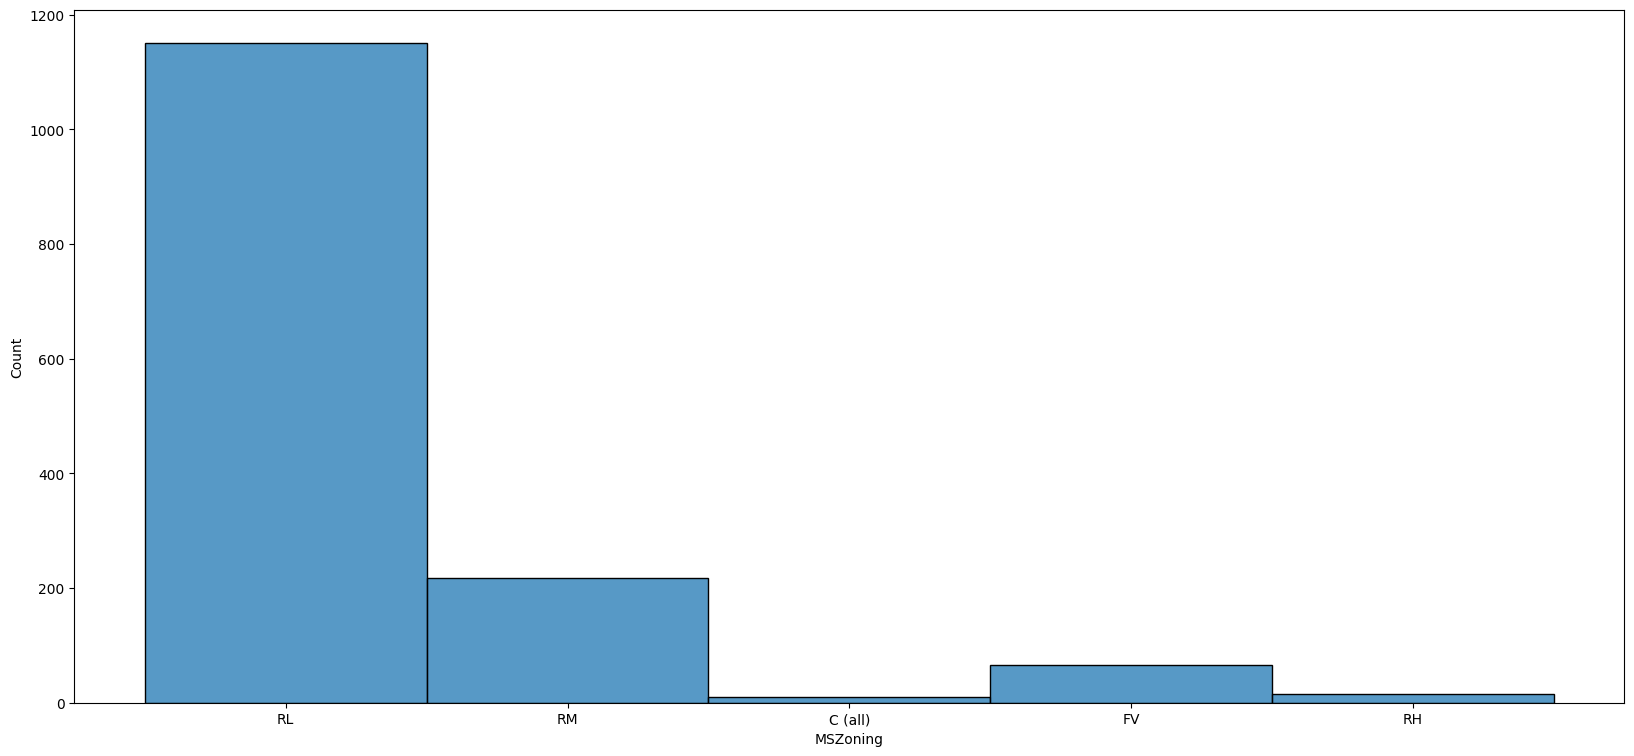

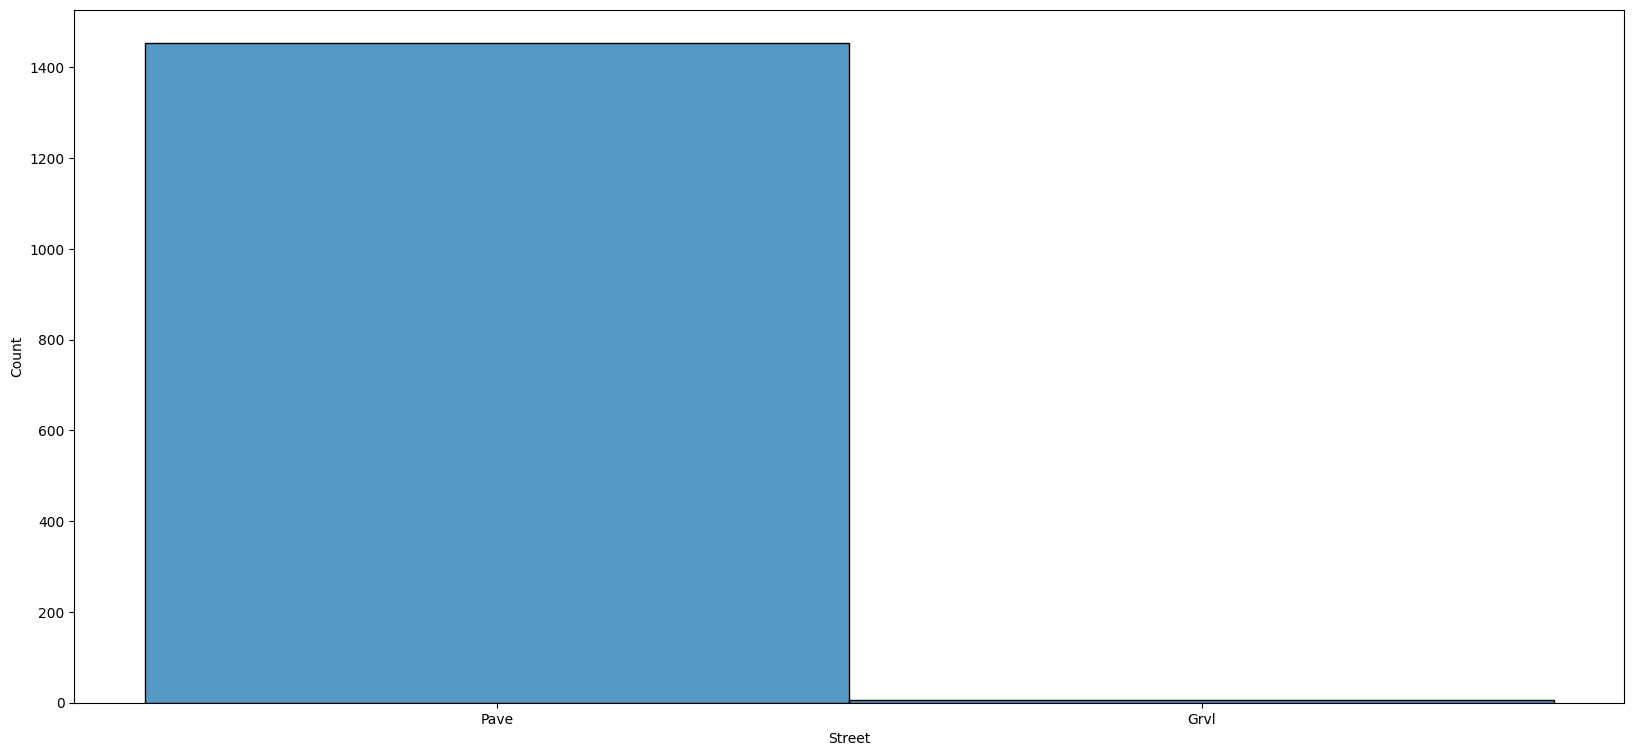

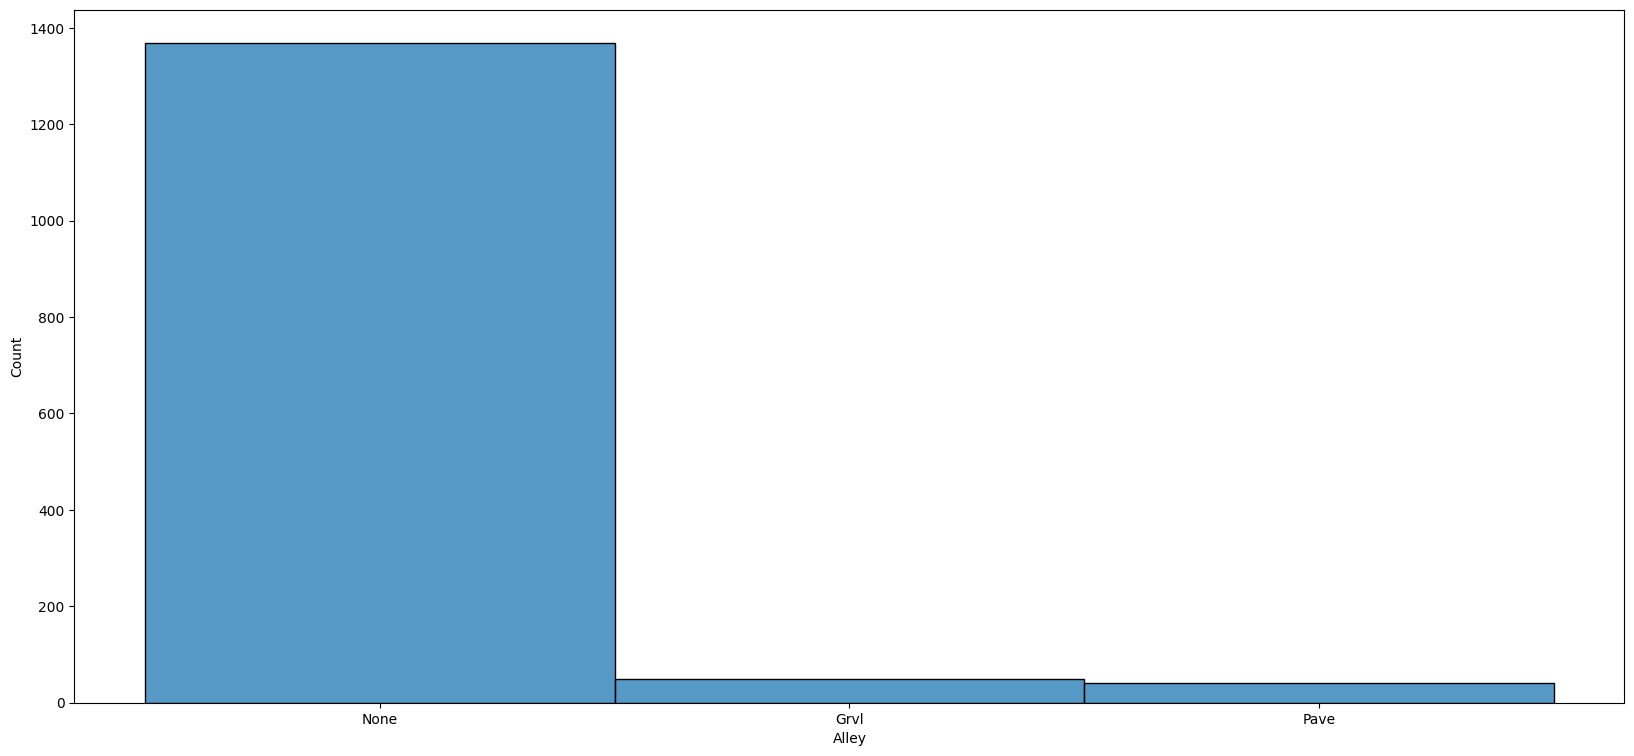

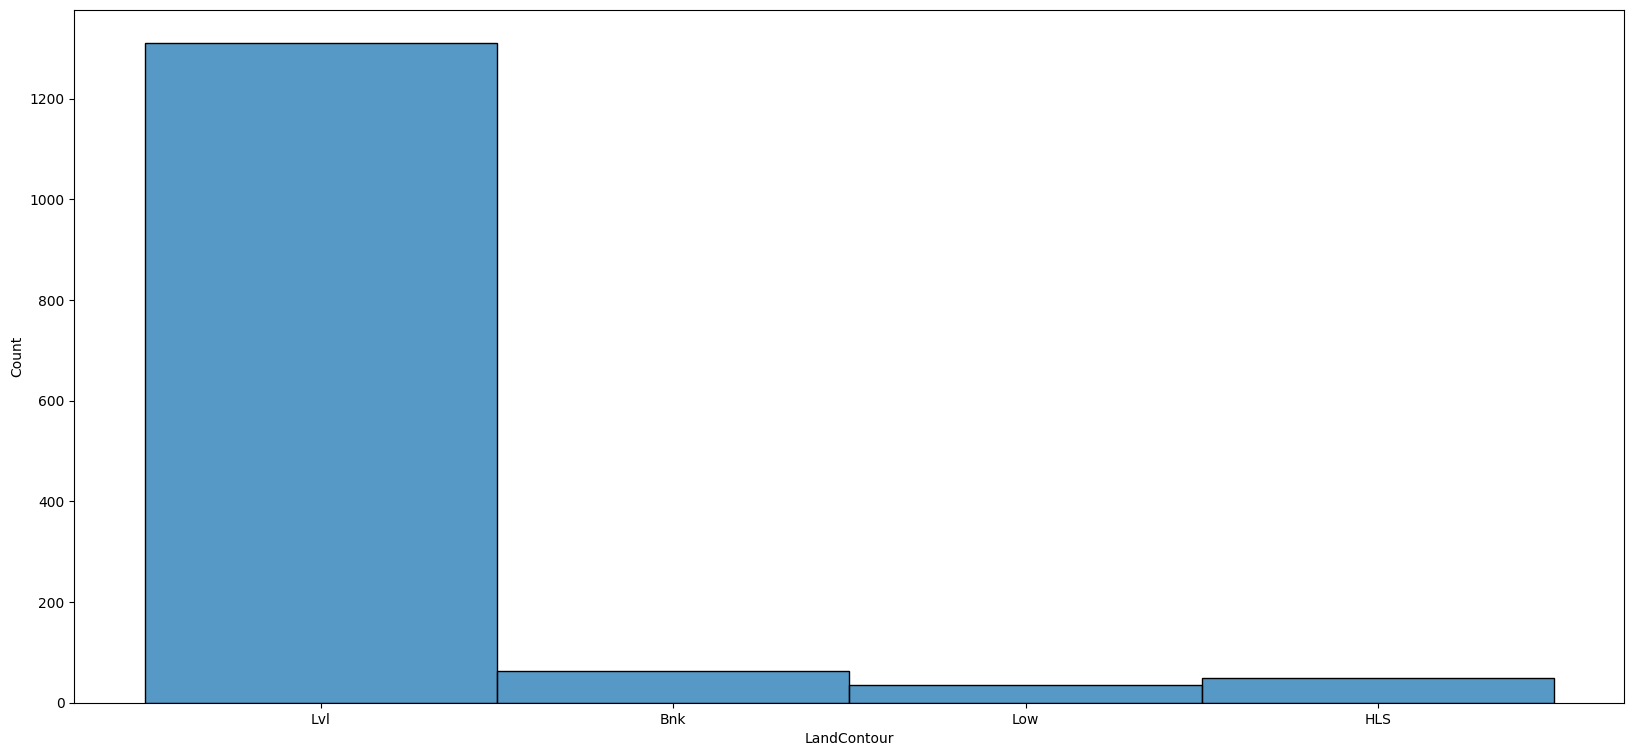

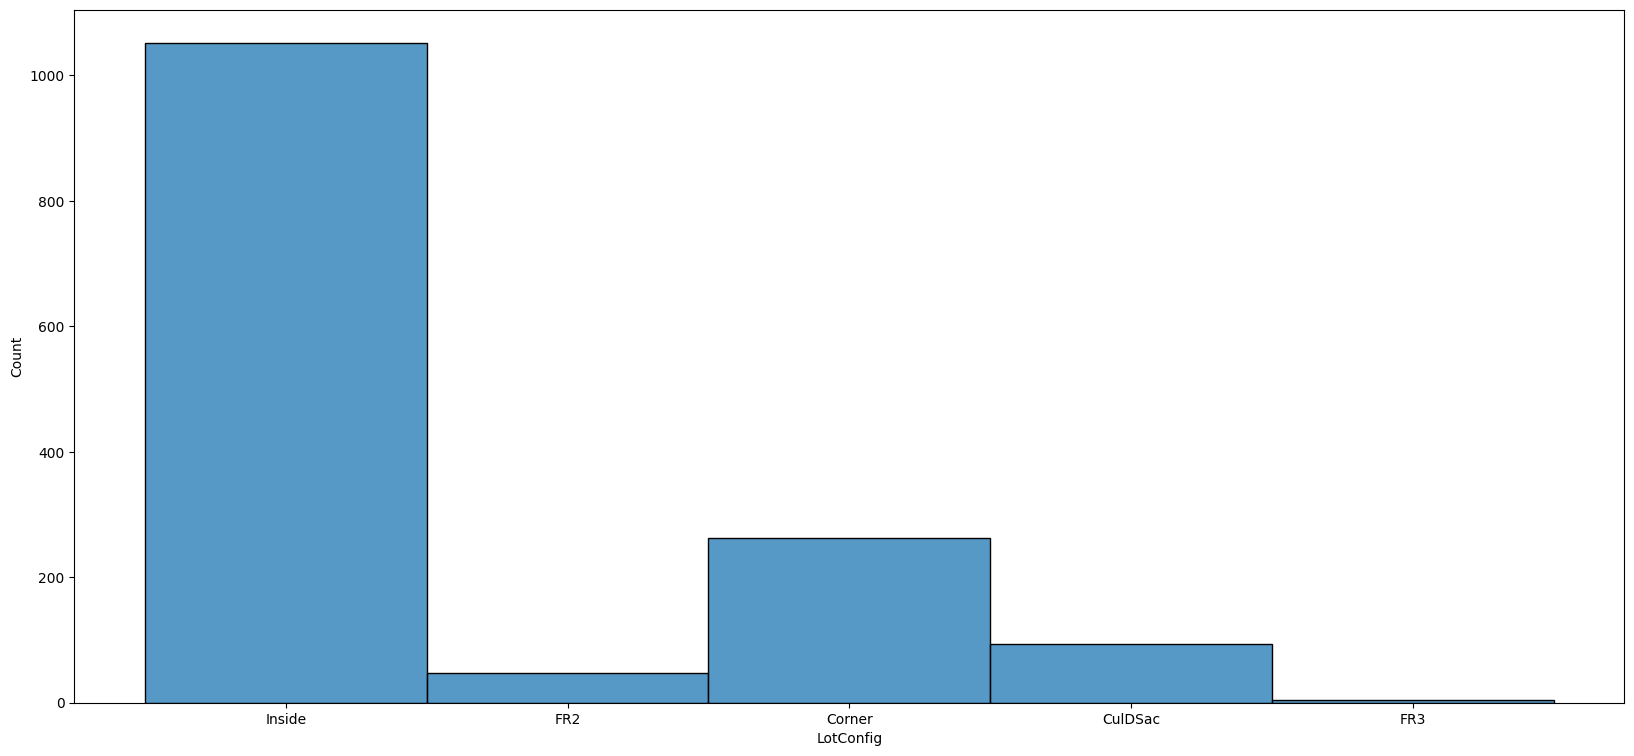

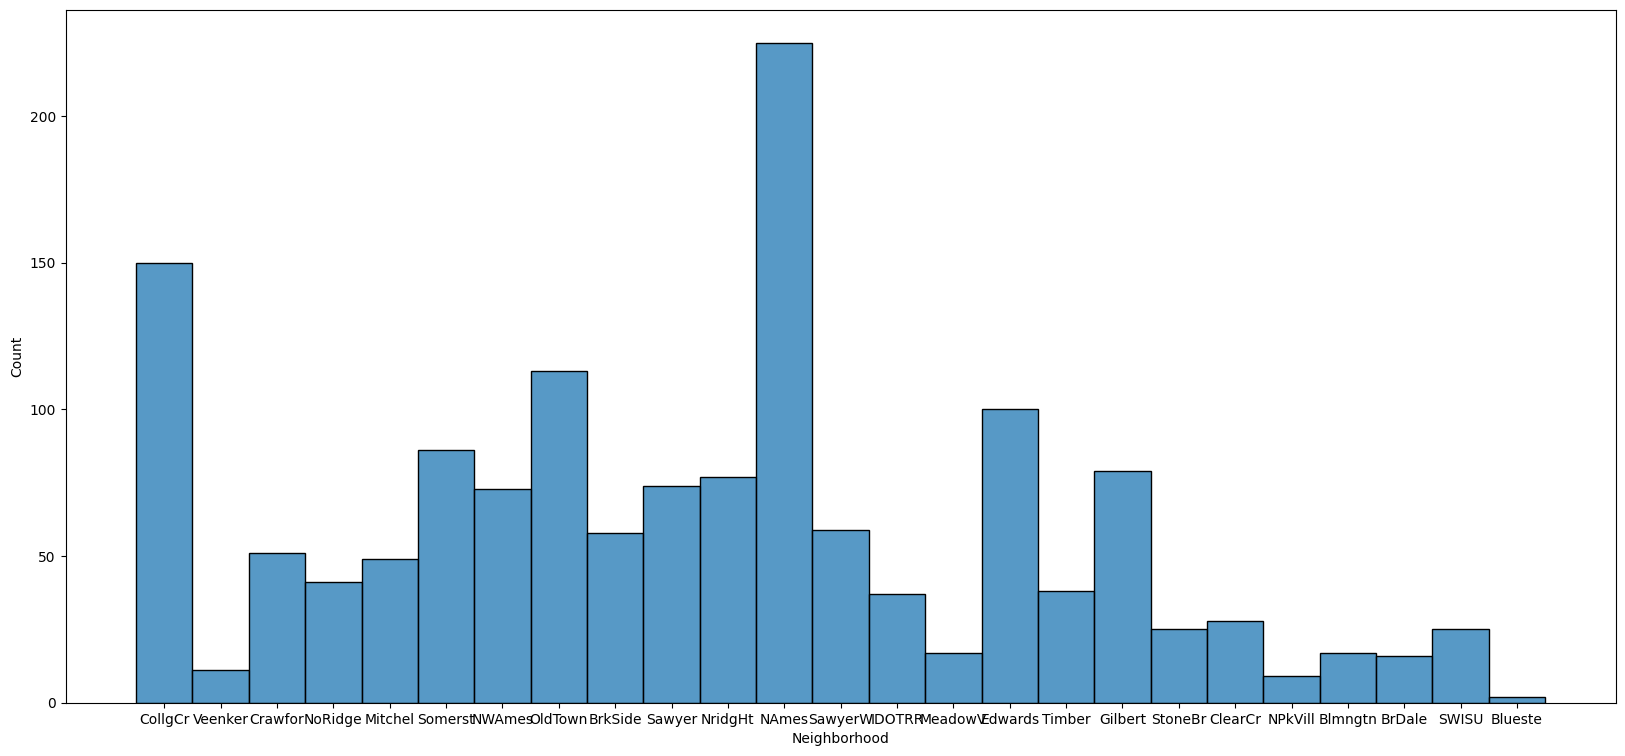

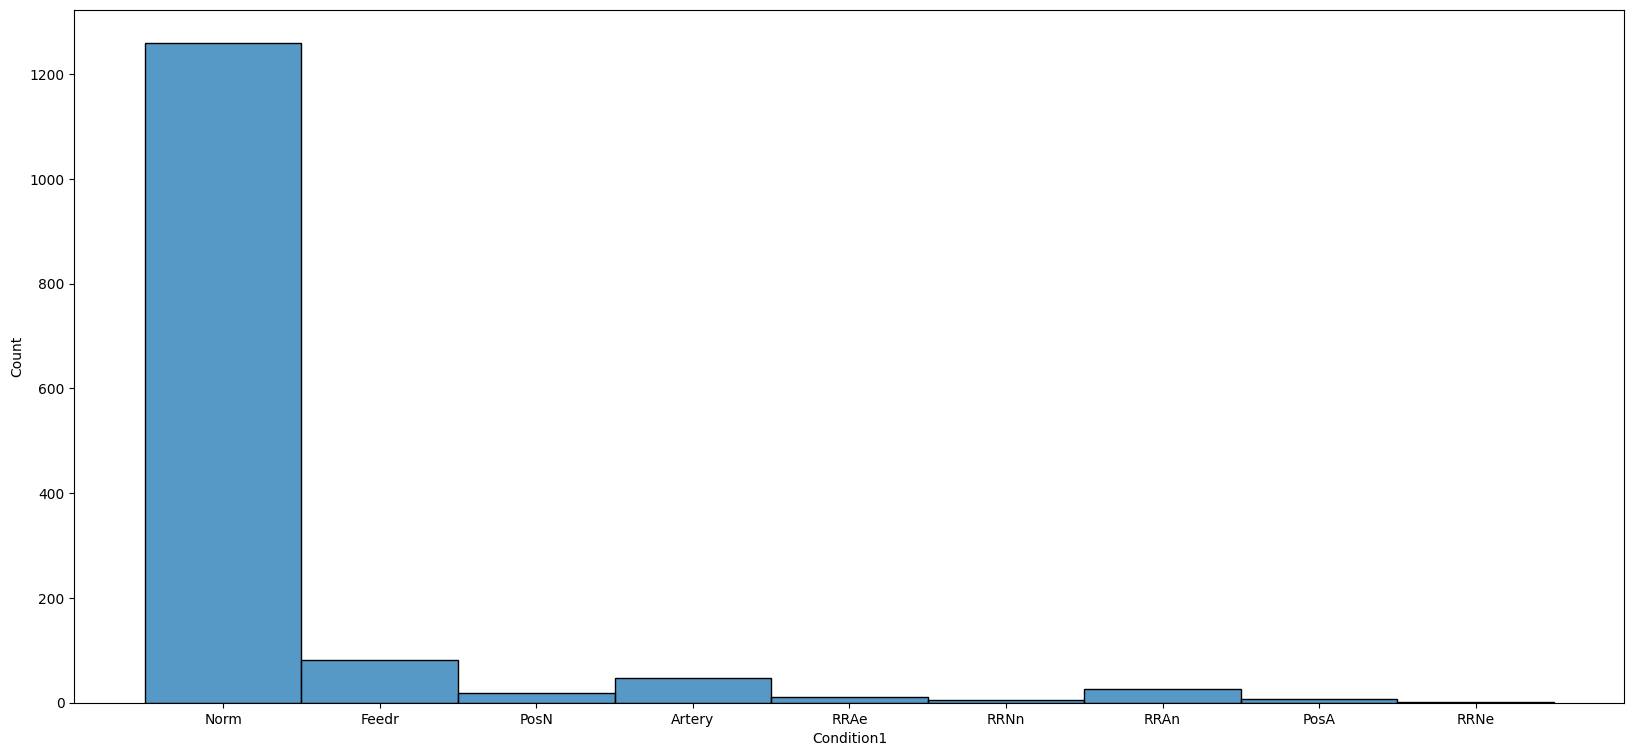

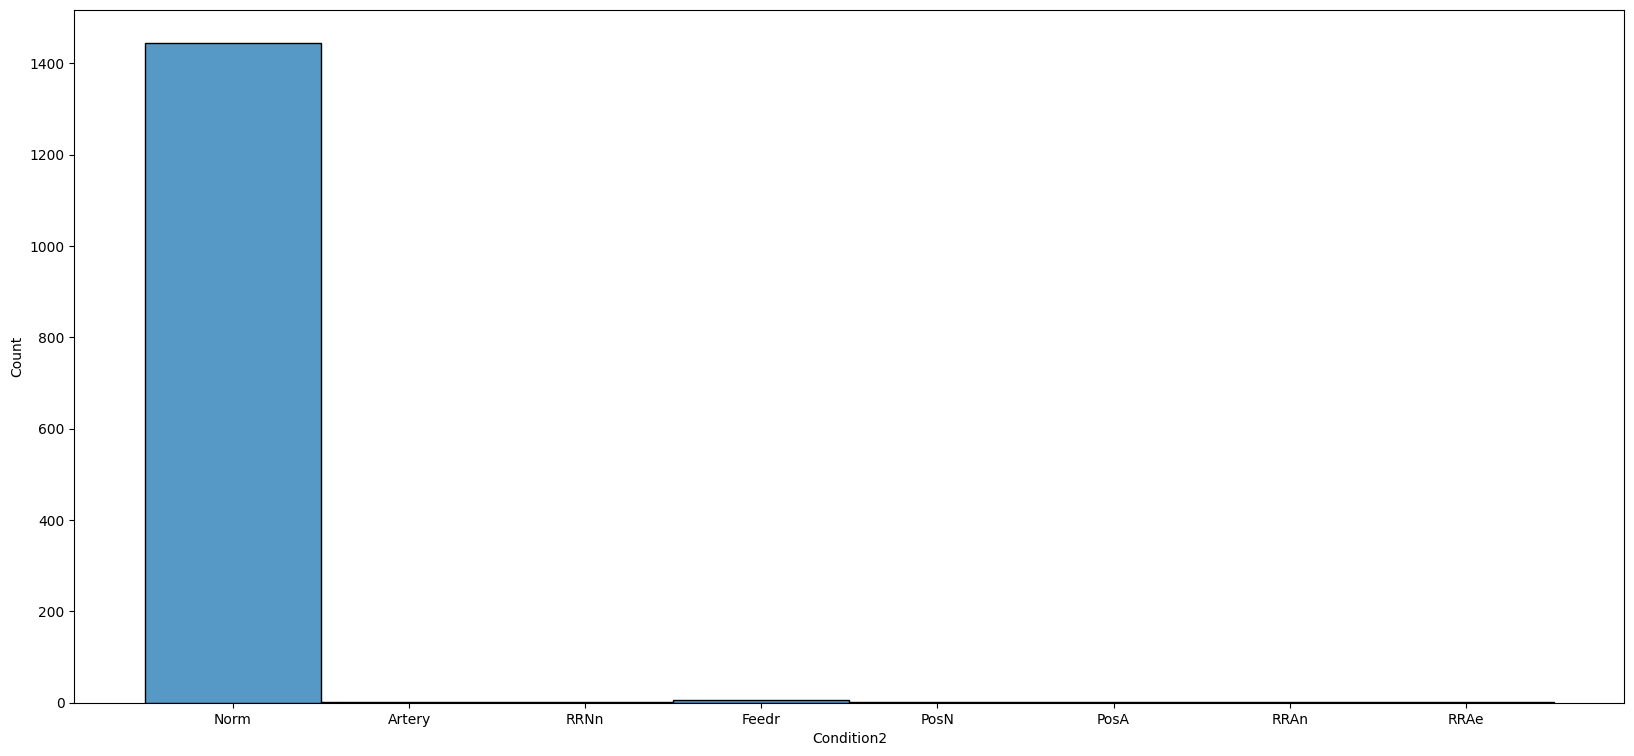

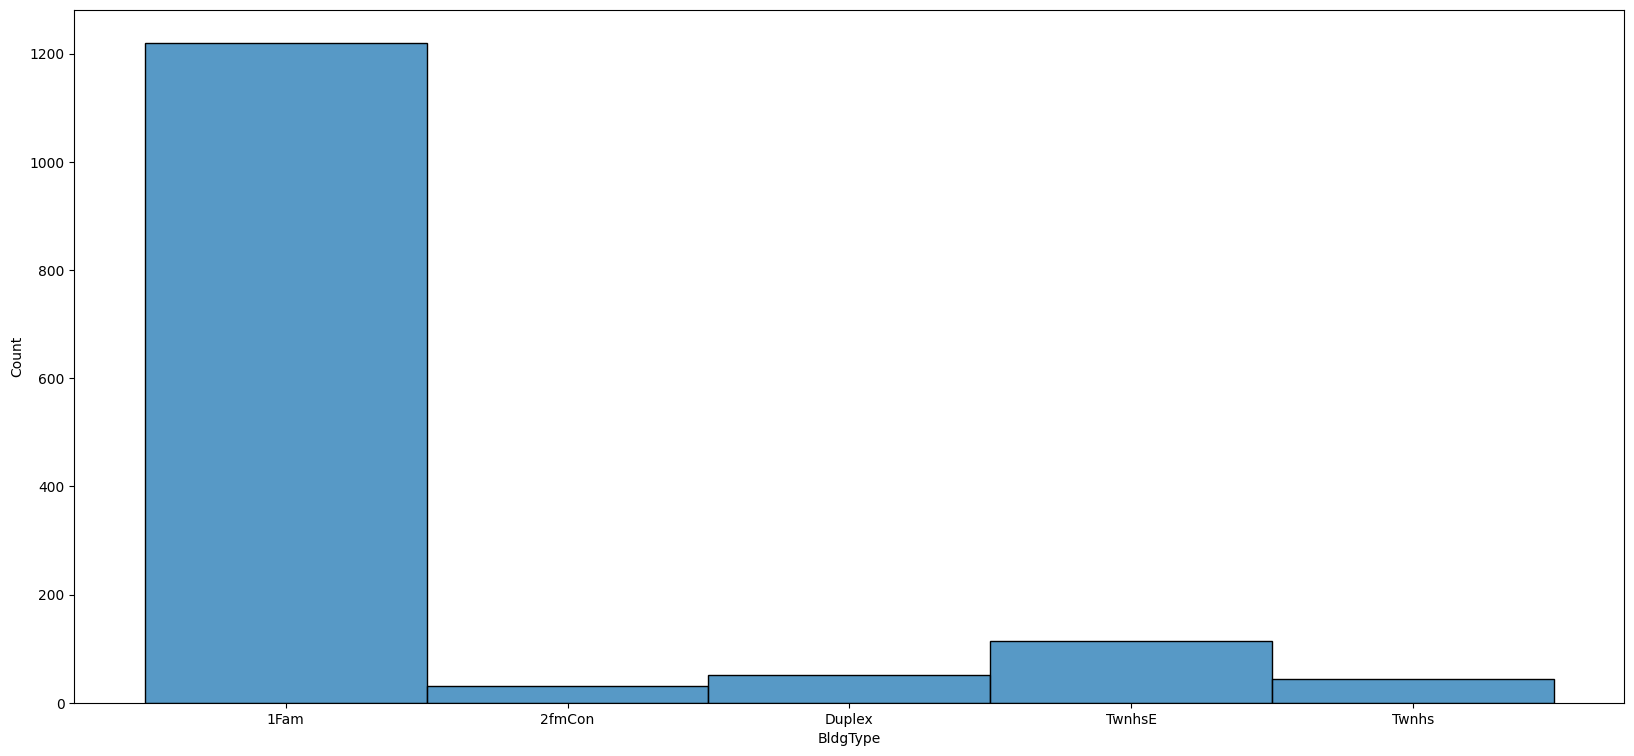

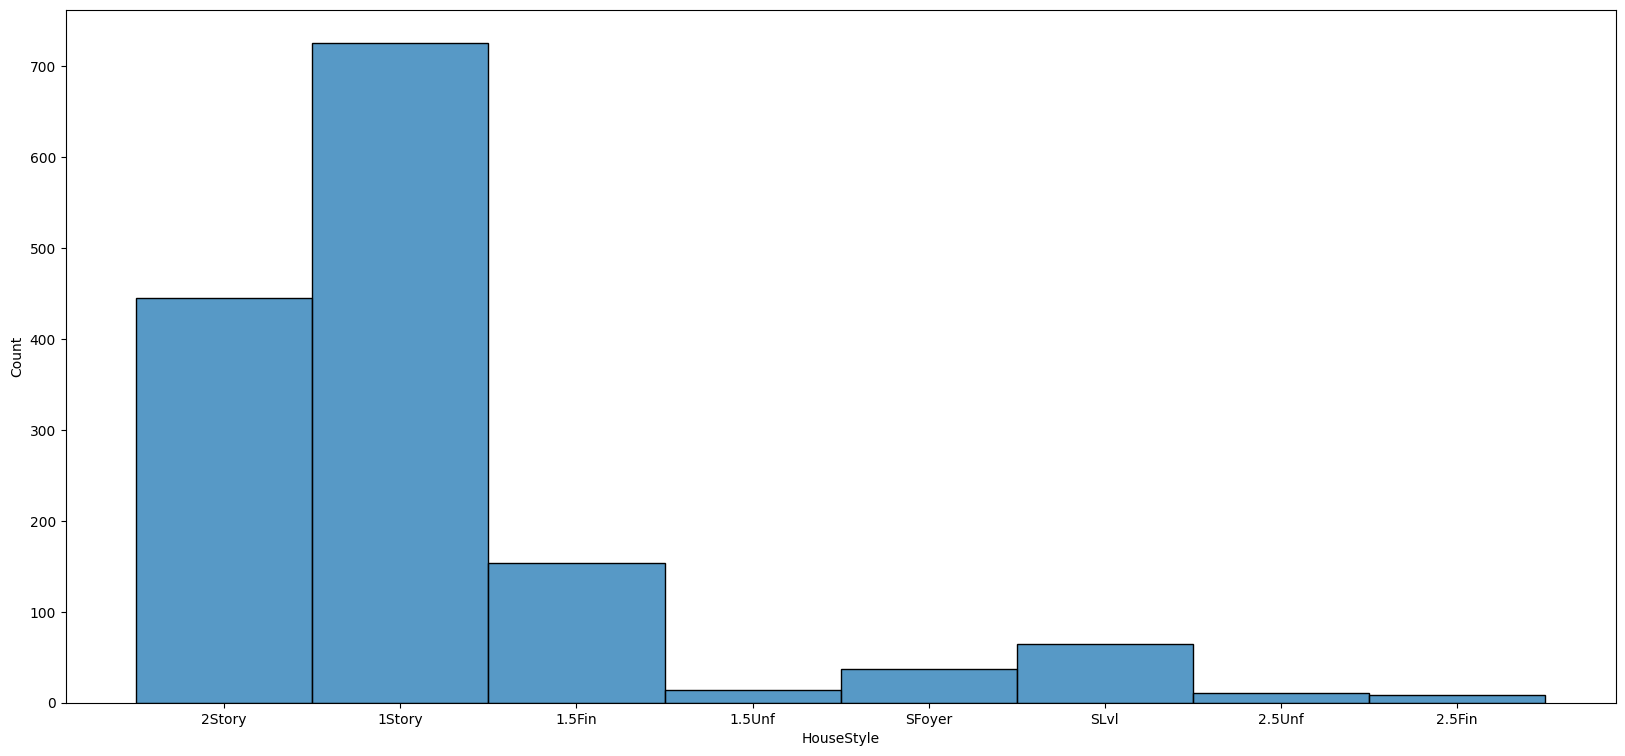

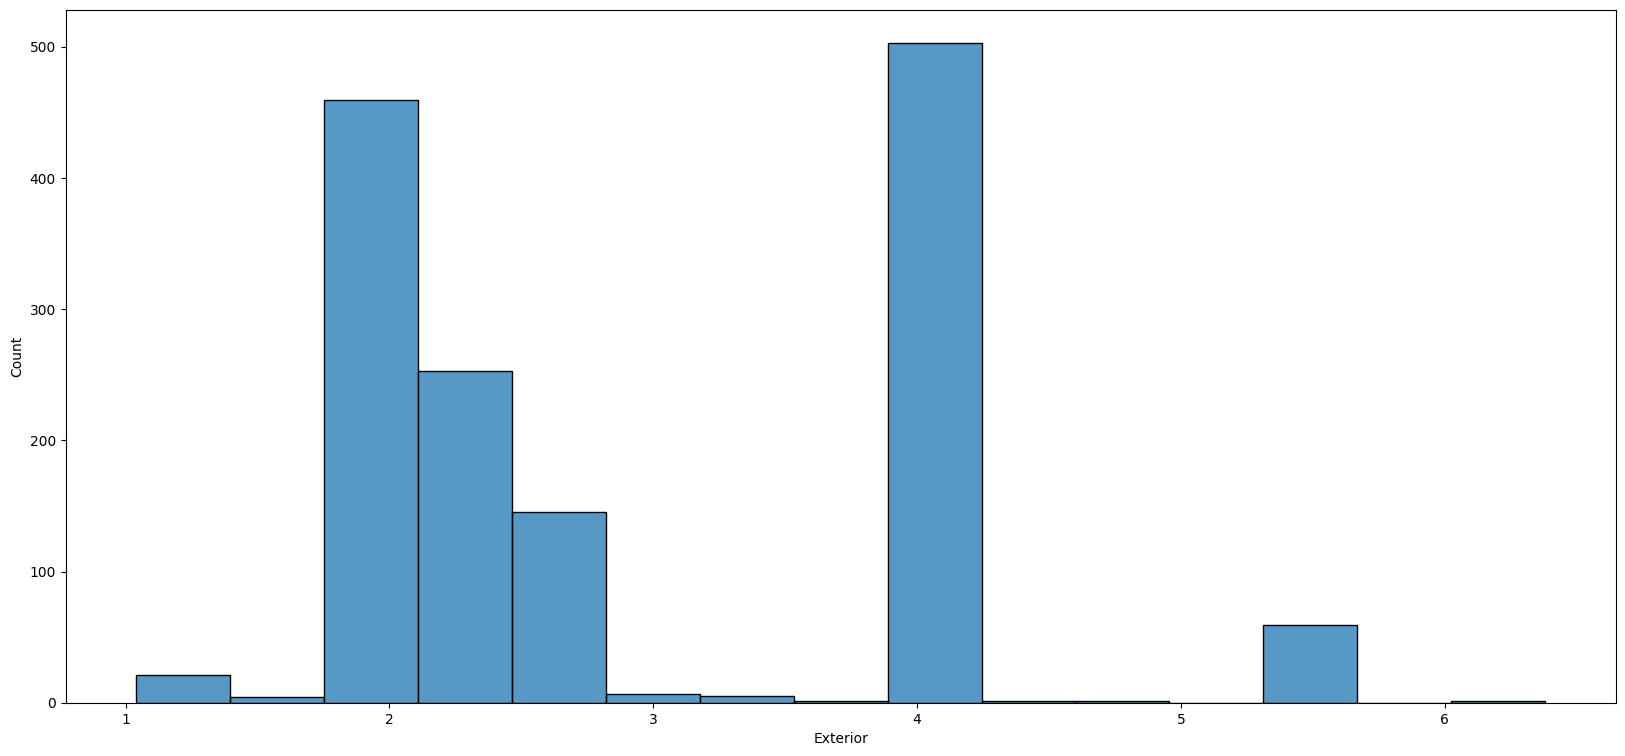

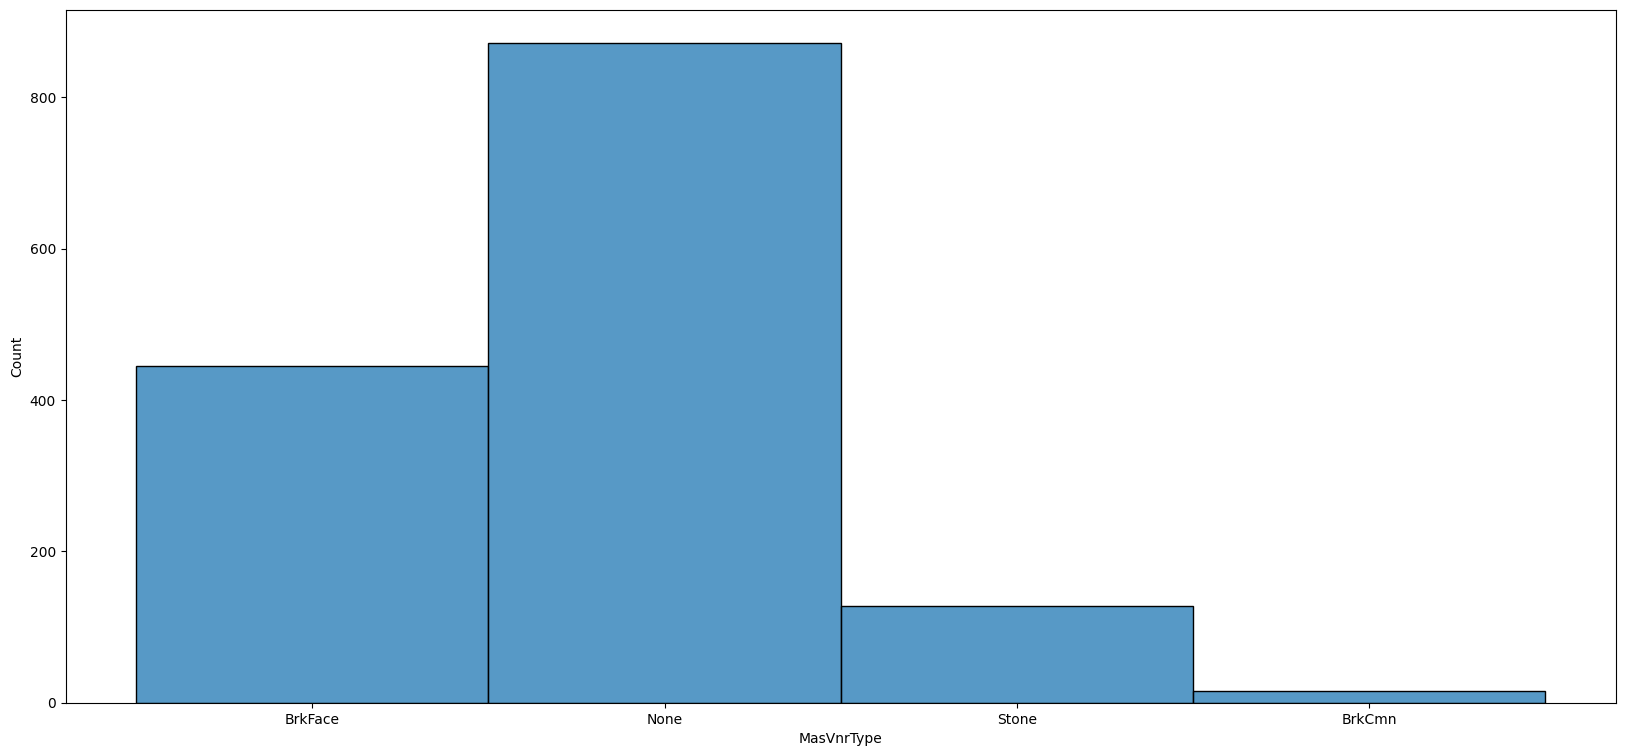

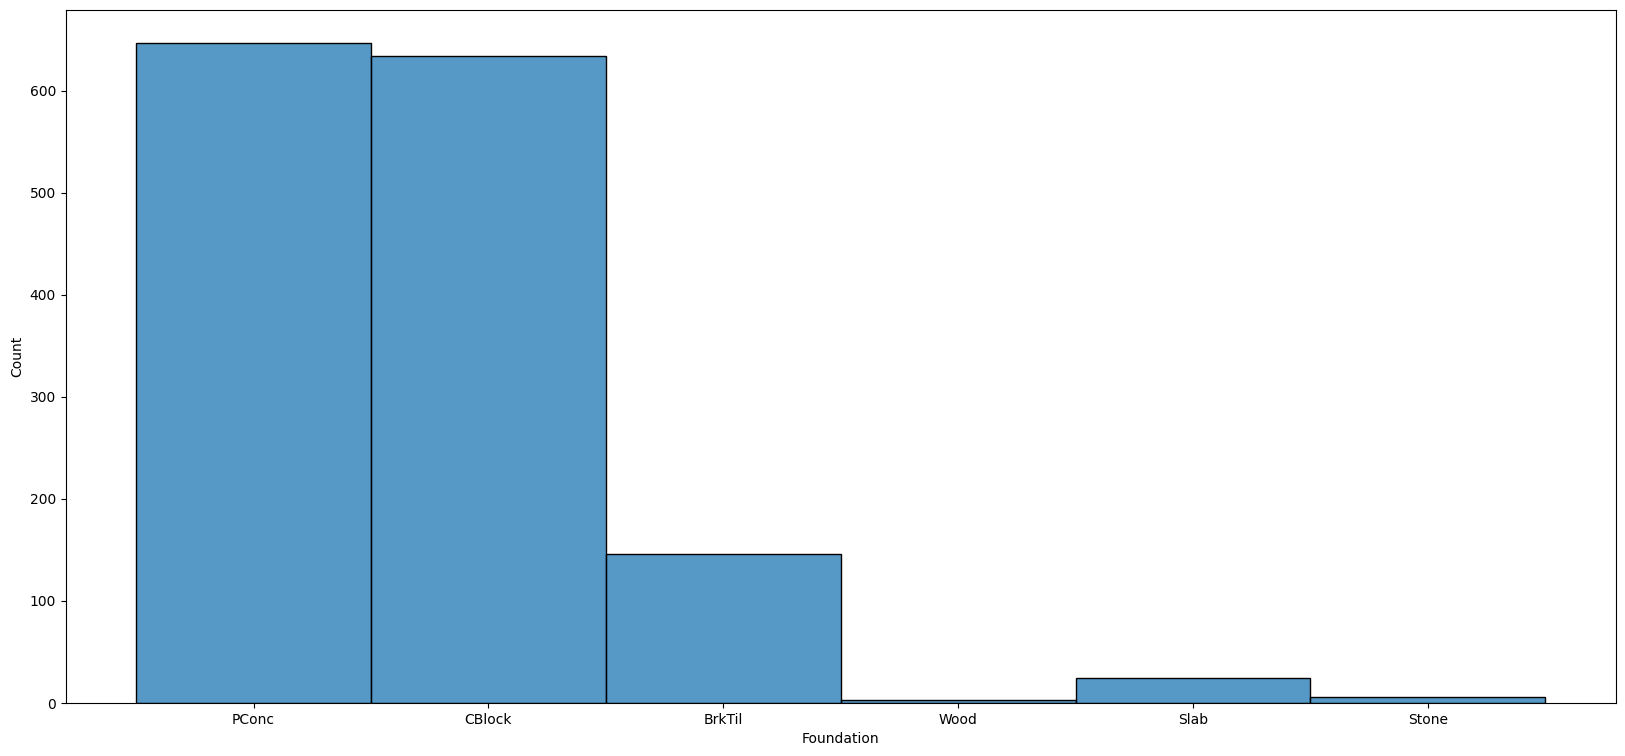

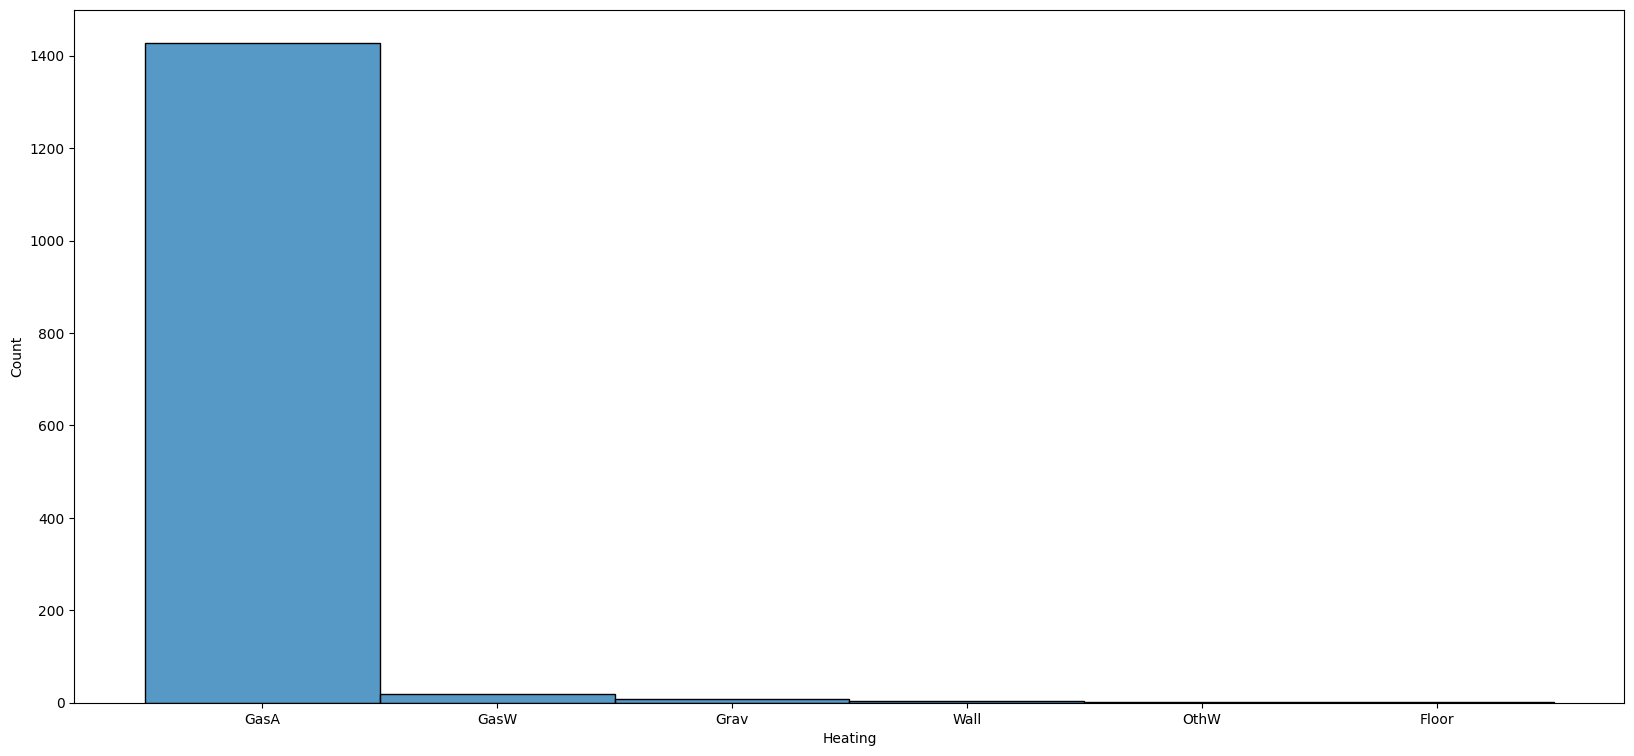

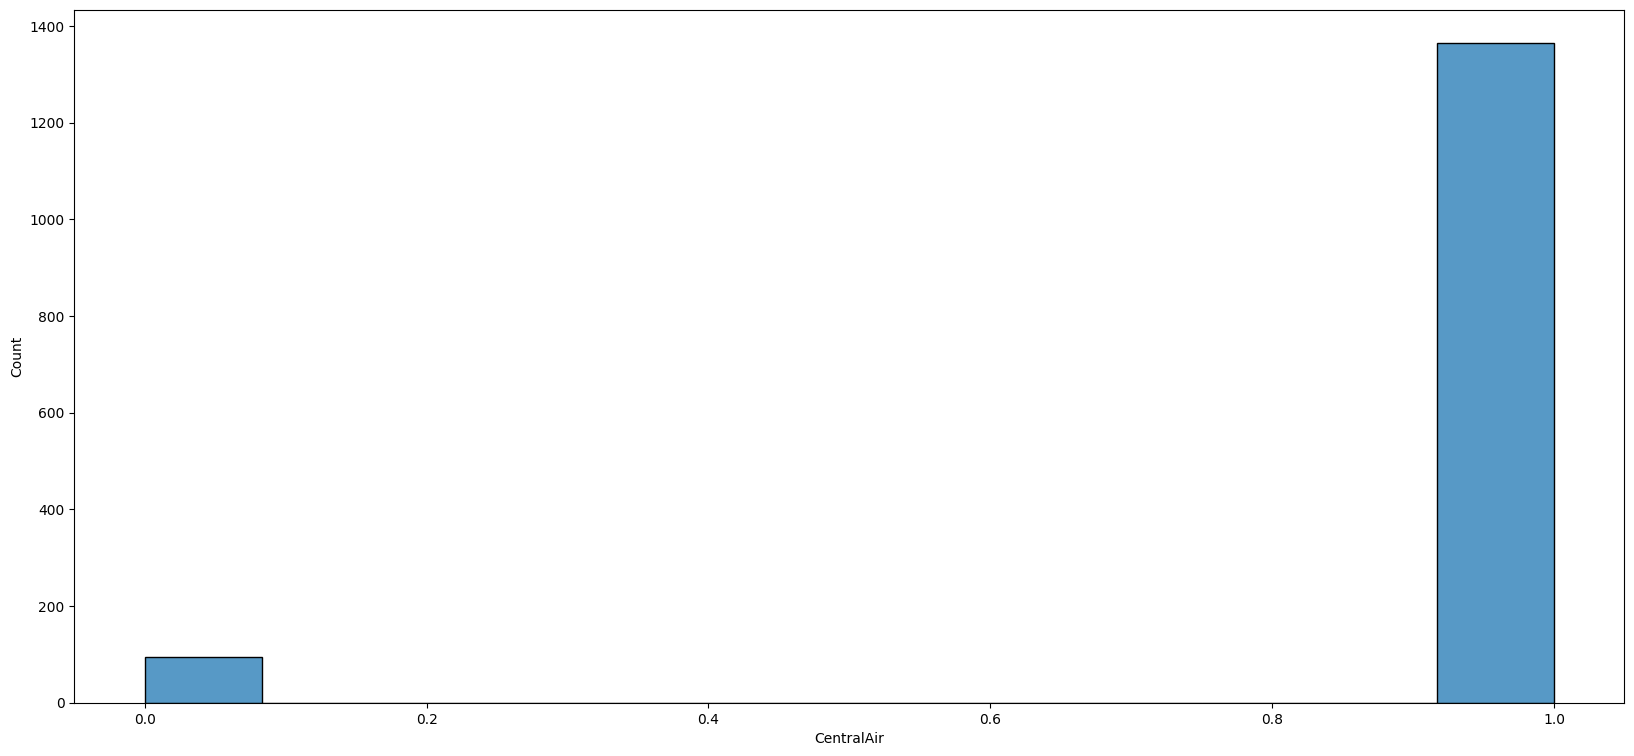

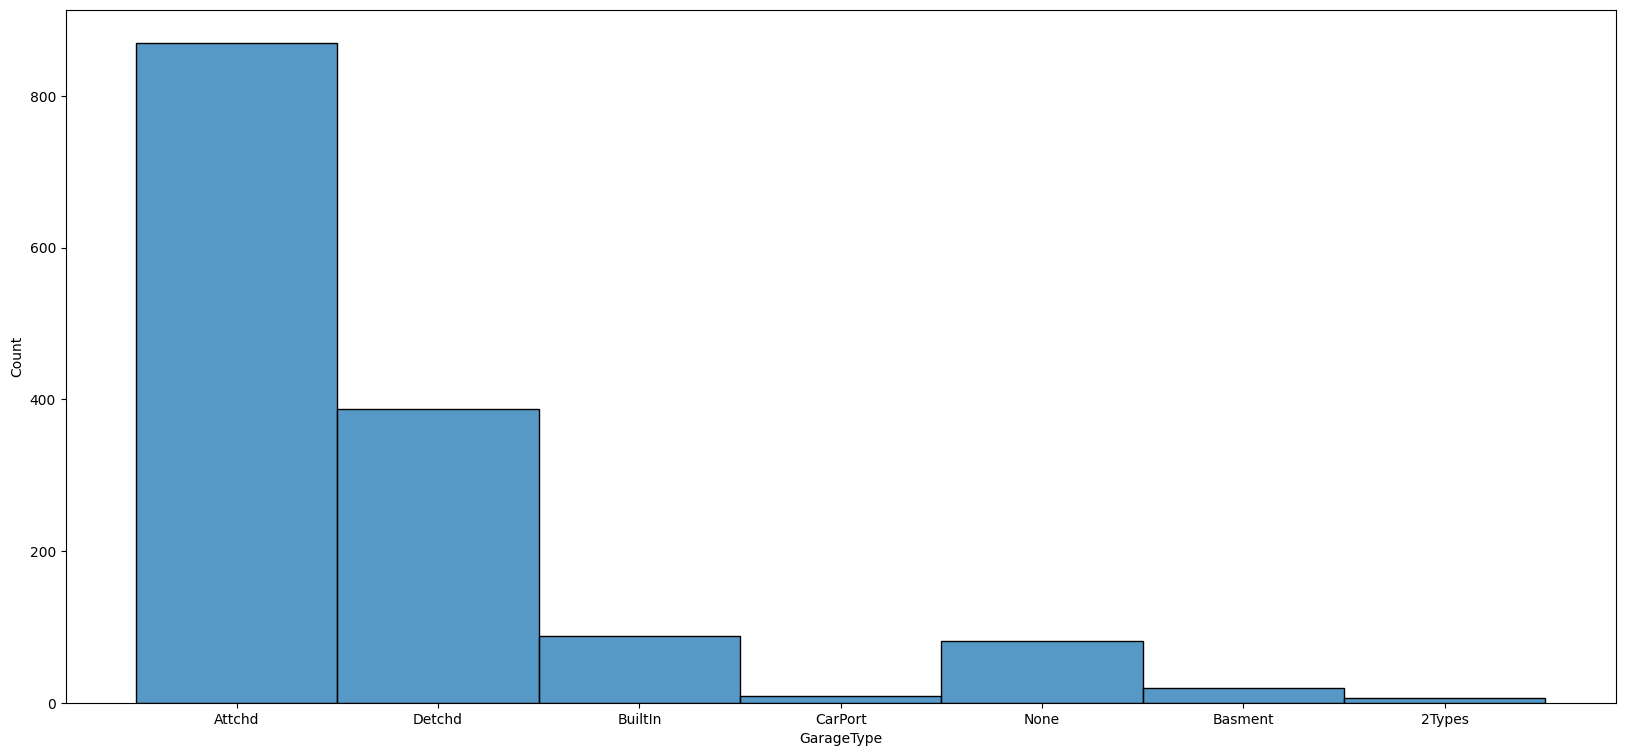

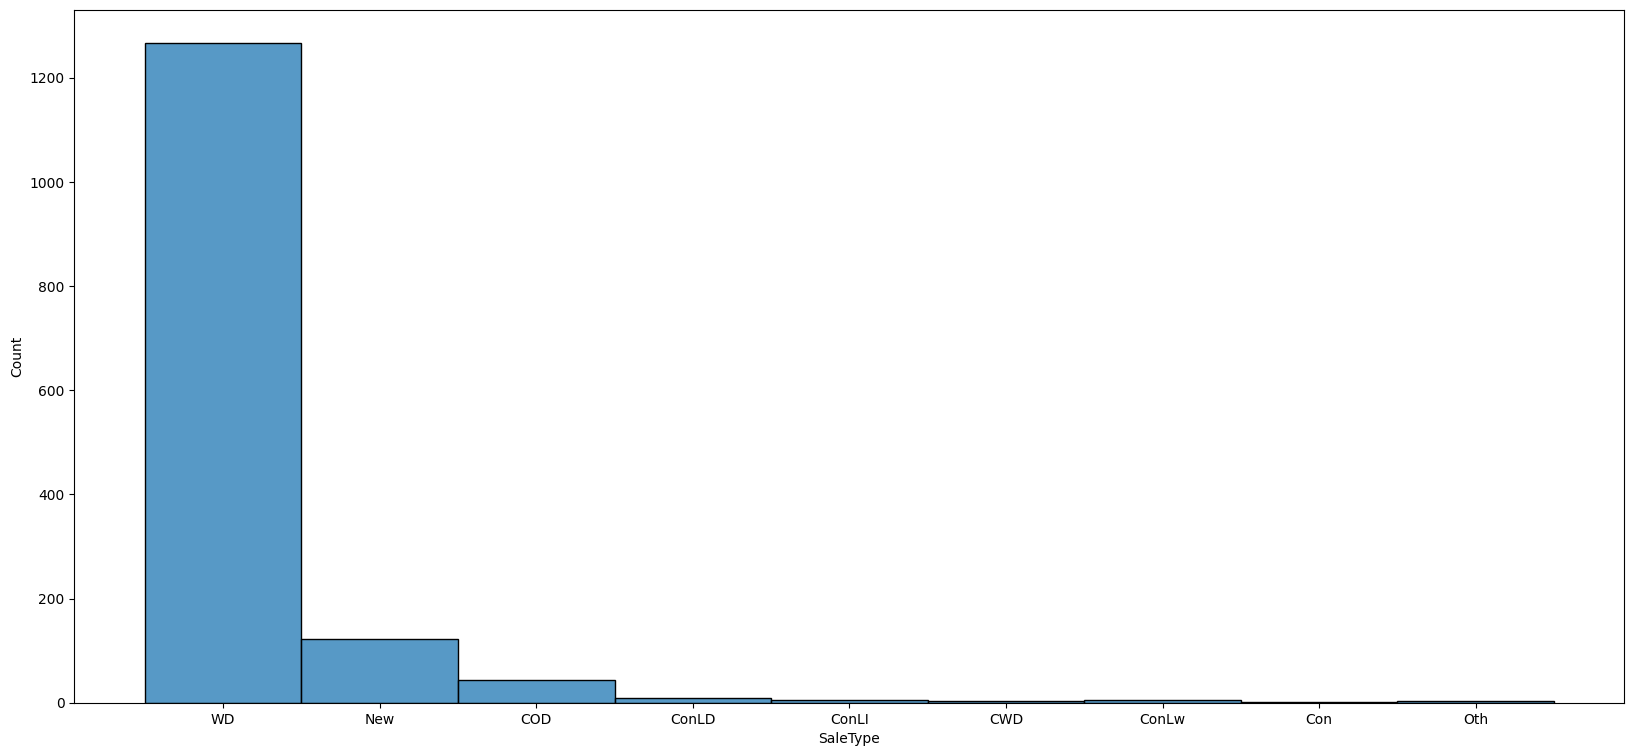

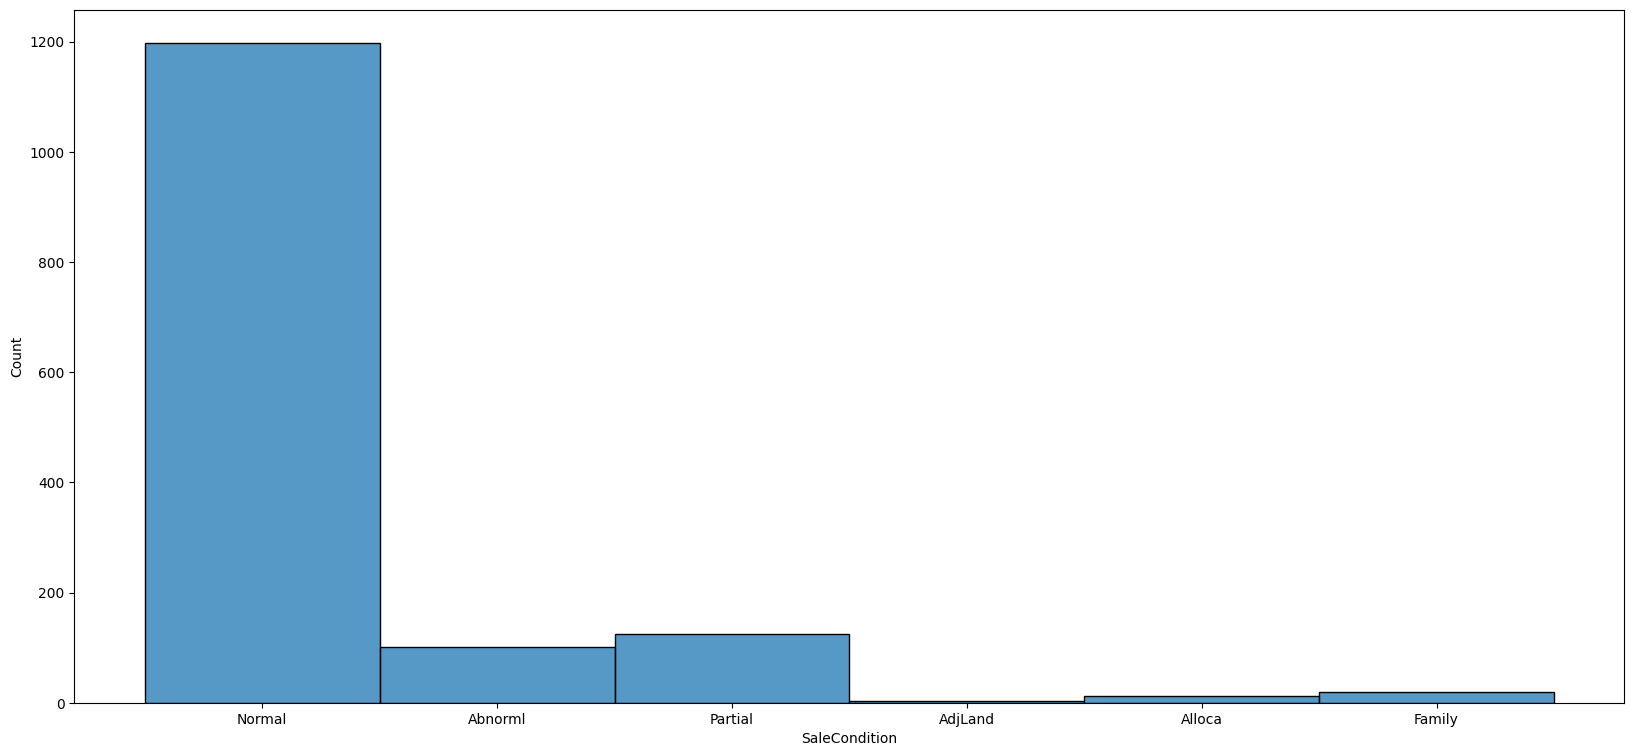

In [104]:
for col in Nominal_col:
    plt.figure(figsize=(20,9))
    sns.histplot(x=col,data=X_cleaned)
    plt.show()

In [105]:
ohe=OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore')

In [106]:
col=ohe.fit_transform(X_cleaned[Nominal_col])
X_new = pd.DataFrame(
    col, 
    columns=ohe.get_feature_names_out(Nominal_col),
    index=X_cleaned.index
)
X_cleaned=pd.concat([X_cleaned.drop(Nominal_col,axis=1),X_new],axis=1)

In [107]:
X_cleaned.columns

Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageFinish',
       'GarageQual', 'GarageCond',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=200)

In [108]:
X_cleaned.head()

,LotFrontage,MasVnrArea,GarageYrBlt,BsmtExposure,BsmtFinType1,BsmtFinType2,FireplaceQu,GarageFinish,GarageQual,GarageCond,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0,196.0,2003.0,No,GLQ,Unf,0,RFn,3,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,80.0,0.0,1976.0,Gd,ALQ,Unf,3,RFn,3,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,68.0,162.0,2001.0,Mn,GLQ,Unf,3,RFn,3,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,60.0,0.0,1998.0,No,ALQ,Unf,4,Unf,3,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,84.0,350.0,2000.0,Av,GLQ,Unf,3,RFn,3,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


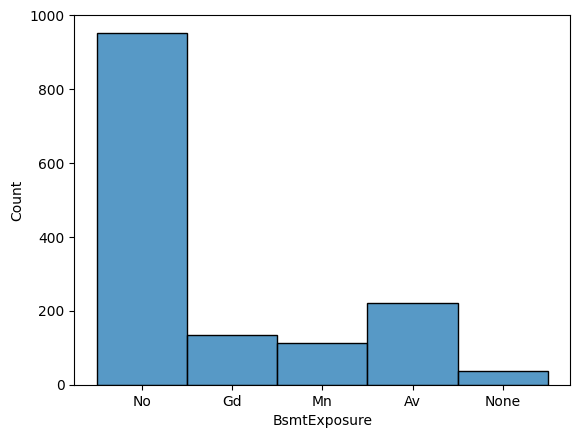

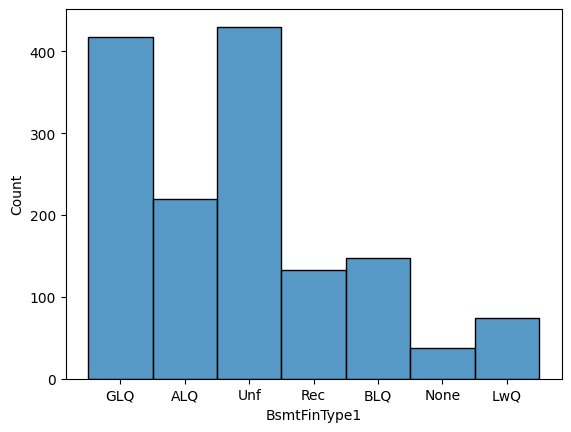

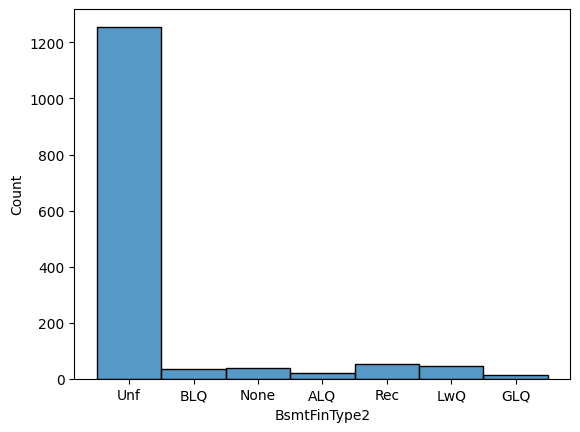

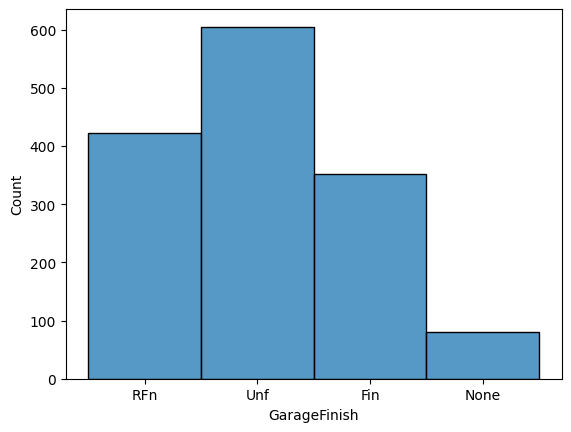

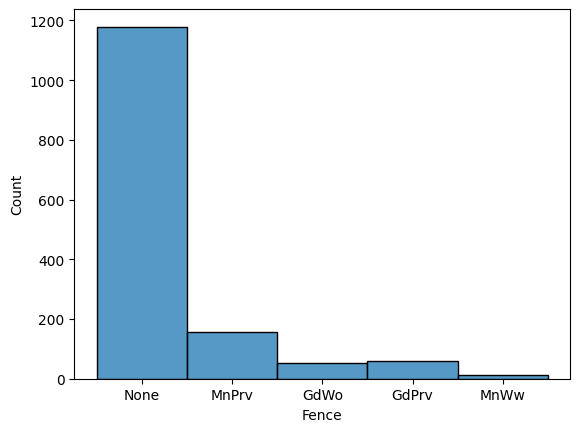

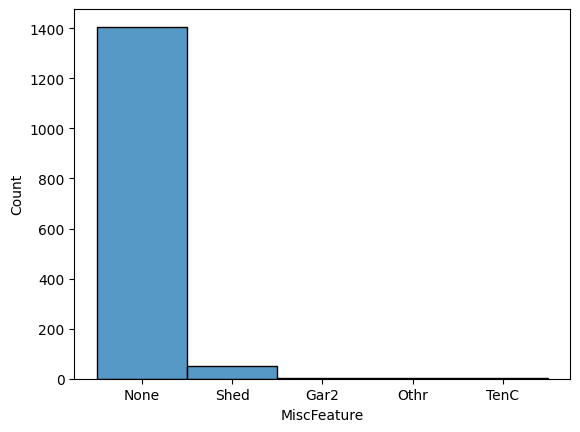

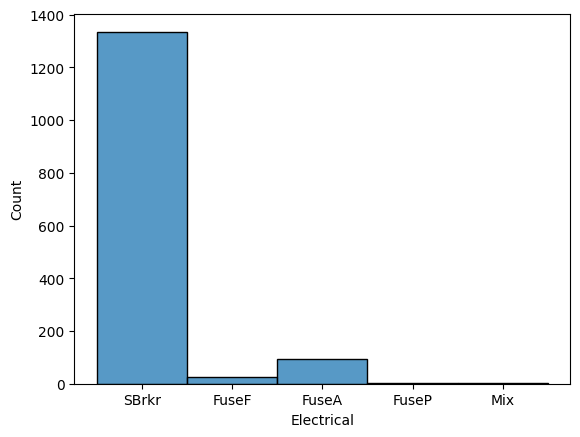

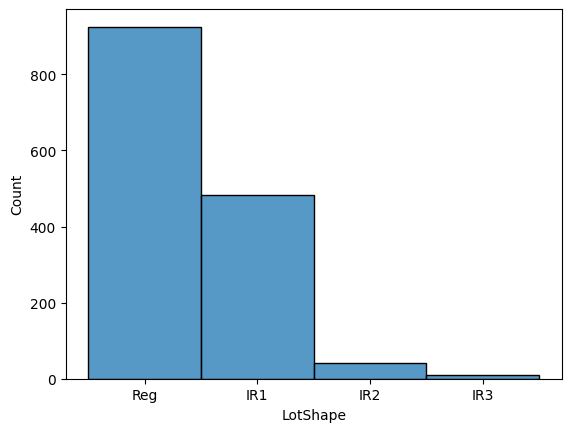

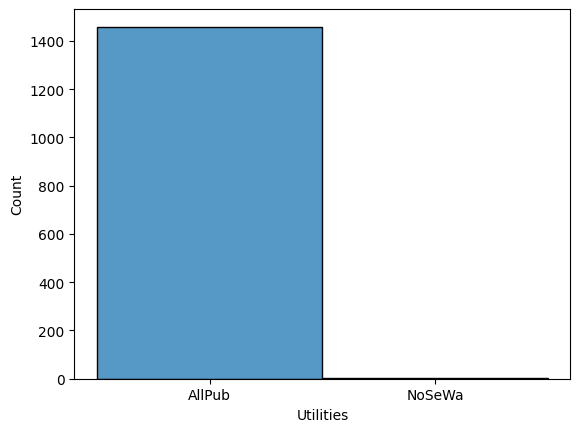

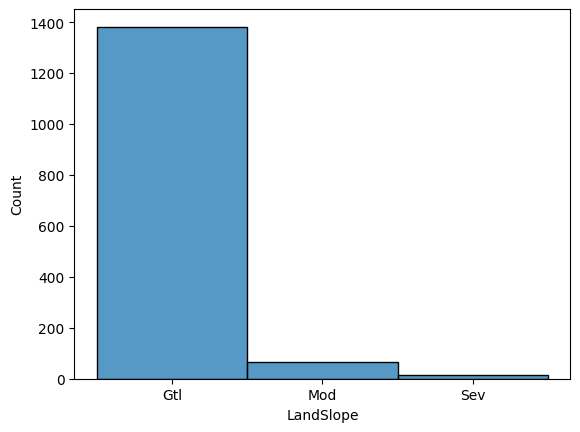

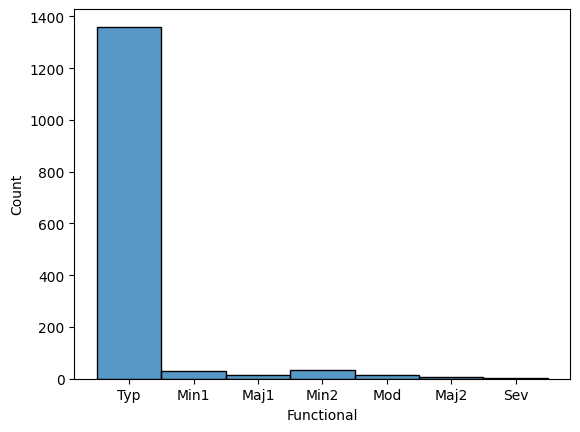

In [109]:
c=['BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Fence',
       'MiscFeature', 'Electrical', 'LotShape', 'Utilities', 'LandSlope',
       'Functional']
for cl in c:
    sns.histplot(x=cl,data=X_cleaned)
    plt.show()

In [110]:
X_cleaned.select_dtypes(include=['object']).columns

Index(['BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Fence',
       'MiscFeature', 'Electrical', 'LotShape', 'Utilities', 'LandSlope',
       'Functional'],
      dtype='object')

BsmtExposure --> Gd Av Mn No NA   
BsmtFinType1 && BsmtFinType2--> GLQ ALQ BLQ Rec LwQ Unf NA   
GarageFinish --> Fun RFn Unf NA   
Fence --> GdPrv MnPrv GdWo MnWw NA   
MiscFeature --> Elev Gar2 Othr Shed TenC NA  
Electrical --> SBrkr FuseA FuseF FuseP  
LotShape --> Reg IR1 IR2 IR3  
Utilities --> ALLPub NoSewr NoSeWa ELO   
LandSlope --> Gtl Mod Sev  
Functional --> Typ Min1 Min2 Mod Maj1 Maj2 Sev Sal  

['AllPub' 'NoSeWa']


<Axes: xlabel='Utilities', ylabel='count'>

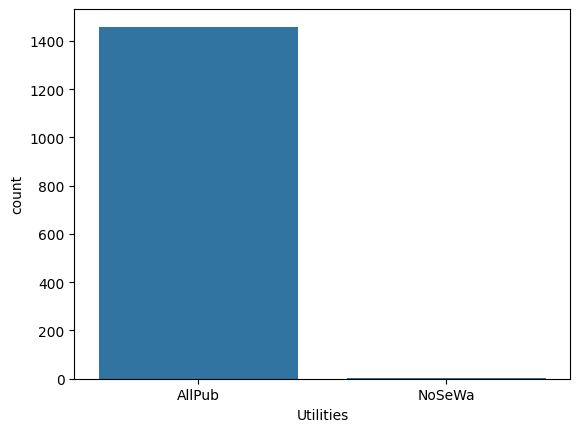

In [111]:
print(X_cleaned['Utilities'].unique())
sns.countplot(x='Utilities',data=X_cleaned)

In [112]:
X_cleaned['Electrical']=X_cleaned['Electrical'].map({
    'SBrkr':4,'FuseA':3,"FuseF":2,'FuseP':1,'Mix':0
})
X_cleaned['LotShape']=X_cleaned['LotShape'].map({
    'Reg':4,'IR1':3,"IR2":2,"IR3":1,'None':0
})
X_cleaned['Utilities']=X_cleaned['Utilities'].map({
    'AllPub':1,'NoSeWa':0
})
X_cleaned['Functional']=X_cleaned['Functional'].map({
    'Typ':7,'Min1':6,'Min2':5,'Mod':4,'Maj1':3,'Maj2':2,'Sev':1,'Sal':0
})
X_cleaned['LandSlope']=X_cleaned['LandSlope'].map({
    'Gtl':2,'Mod':1,'Sev':0
})

X_cleaned['MiscFeature']=X_cleaned['MiscFeature'].map({
    'Elev':5,'Gar2':4,'Othr':3,'Shed':2,'TenC':1,'None':0
})
X_cleaned['Fence']=X_cleaned['Fence'].map({
    'GdPrv':4,'MnPrv':3,'GdWo':2,'MnWw':1,'None':0
})

X_cleaned['GarageFinish']=X_cleaned['GarageFinish'].map({
    'Fin':3,
    'RFn':2,
    'Unf':1,
    'None':0
})

X_cleaned['BsmtExposure']=X_cleaned['BsmtExposure'].map({
    'Ex':5,
    'Gd':4,
    'Av':3,
    'Mn':2,
    'No':1,
    'None':0
})
X_cleaned['BsmtFinType1']=X_cleaned['BsmtFinType1'].map({
    'GLQ':6, 'ALQ':5 ,'BLQ':4 ,'Rec':3, 'LwQ':2, 'Unf':1 ,'None':0
})
X_cleaned['BsmtFinType2']=X_cleaned['BsmtFinType2'].map({
    'GLQ':6, 'ALQ':5 ,'BLQ':4 ,'Rec':3, 'LwQ':2, 'Unf':1 ,'None':0
})

In [113]:
X['BsmtFinType1'].unique()

array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ'], dtype=object)

In [114]:
X_cleaned.head()

,LotFrontage,MasVnrArea,GarageYrBlt,BsmtExposure,BsmtFinType1,BsmtFinType2,FireplaceQu,GarageFinish,GarageQual,GarageCond,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0,196.0,2003.0,1,6,1,0,2,3,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,80.0,0.0,1976.0,4,5,1,3,2,3,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,68.0,162.0,2001.0,2,6,1,3,2,3,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,60.0,0.0,1998.0,1,5,1,4,1,3,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,84.0,350.0,2000.0,3,6,1,3,2,3,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [115]:
X_cleaned.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [116]:
X_cleaned.columns

Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageFinish',
       'GarageQual', 'GarageCond',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=200)

# Model Training 

In [218]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import accuracy_score , mean_squared_error, mean_absolute_error,r2_score

In [118]:
y_log=np.log1p(y)

In [119]:
X_train,X_test,y_train,y_test=train_test_split(X_cleaned,y_log.round(2),test_size=0.2,random_state=59)

In [120]:
y_log

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: SalePrice, Length: 1460, dtype: float64

In [121]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [122]:
lgr=LinearRegression(
    n_jobs=-1,
)

In [123]:
lgr.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [124]:
lgr_pred=lgr.predict(X_test_scaled)

In [125]:
test_mae=mean_absolute_error(lgr_pred,y_test)

In [126]:
test_mse=mean_squared_error(lgr_pred,y_test)

In [127]:
lgr_train_pred=lgr.predict(X_train_scaled)

In [128]:
train_mae=mean_absolute_error(y_train,lgr_train_pred)

In [129]:
train_mse=mean_squared_error(y_train,lgr_train_pred)

In [130]:
r2=r2_score(lgr_pred,y_test)

In [131]:
print("Test Mean Absolute error: ",test_mae)
print("Train Mean Absolute error: ",train_mae)
print("Test Mean Squared error: ",test_mse)
print("Train Mean Squared error: ",train_mse)
print("Test Root Mean Squared error: ",np.sqrt(test_mse))
print("Train Root Mean Squared error: ",np.sqrt(train_mse))
print("R2_Score(coefficient of determination) :",r2)

Test Mean Absolute error:  0.09184667821141679
Train Mean Absolute error:  0.07616076294593262
Test Mean Squared error:  0.018751034160688705
Train Mean Squared error:  0.012163627490723954
Test Root Mean Squared error:  0.13693441554513863
Train Root Mean Squared error:  0.11028883665504843
R2_Score(coefficient of determination) : 0.8755075799463672


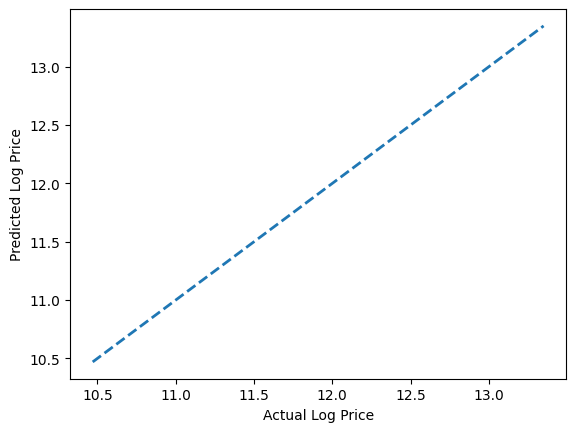

In [132]:
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', lw=2)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.show()

Residual is showing **Homoscedasticity**

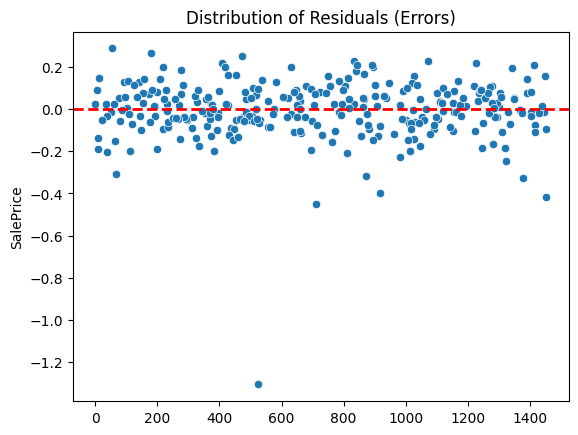

In [133]:
lgr_residuals=y_test-lgr_pred
sns.scatterplot(lgr_residuals)
plt.title("Distribution of Residuals (Errors)")
plt.axhline(0, color='r', linestyle='--',lw=2)
plt.show()

Residual --> follows a **Normal Distribution**

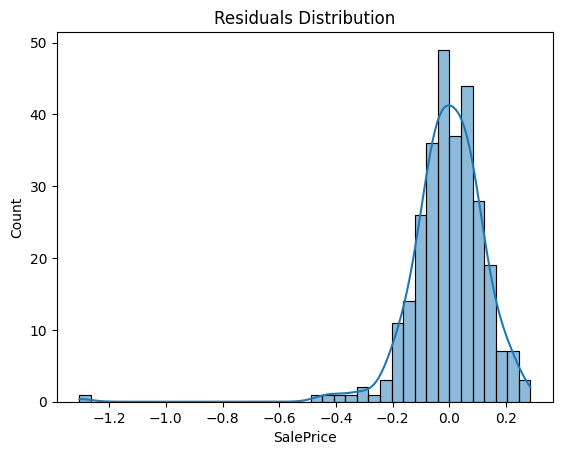

In [134]:
sns.histplot(lgr_residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

In [135]:
lgr_feat=pd.DataFrame({
    'Feature':X_train.columns,
    'Coefficient':lgr.coef_
})
lgr_feat['abs_coef']=lgr_feat['Coefficient'].abs()
lgr_feat.sort_values(by='abs_coef',ascending =False,inplace=True)
lgr_feat

,Feature,Coefficient,abs_coef
51,Total_House_SF,2.286441e-01,2.286441e-01
55,MSZoning_RL,1.602398e-01,1.602398e-01
23,BsmtFinSF1,-1.336626e-01,1.336626e-01
25,BsmtUnfSF,-1.292840e-01,1.292840e-01
161,Exterior_4.0,1.268629e-01,1.268629e-01
...,...,...,...
102,Condition2_PosN,-1.142744e-04,1.142744e-04
5,BsmtFinType2,8.209710e-05,8.209710e-05
124,Exterior_1.83,-7.524363e-17,7.524363e-17
162,Exterior_4.01,9.107298e-18,9.107298e-18


In [136]:
lgr_feat.head()

,Feature,Coefficient,abs_coef
51,Total_House_SF,0.228644,0.228644
55,MSZoning_RL,0.160240,0.160240
23,BsmtFinSF1,-0.133663,0.133663
25,BsmtUnfSF,-0.129284,0.129284
161,Exterior_4.0,0.126863,0.126863


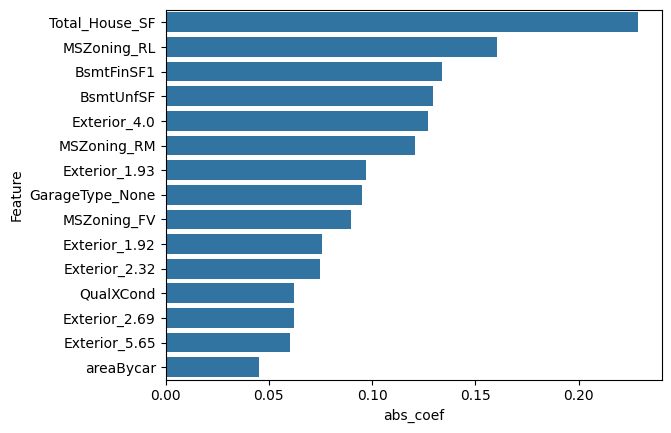

In [138]:
sns.barplot(x='abs_coef',y='Feature',data=lgr_feat.head(15))
plt.show()

In [203]:
Ls=Lasso(alpha=0.001,
         max_iter=10000
        )

In [204]:
Ls.fit(X_train_scaled,y_train)

,alpha,0.001
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [205]:
ls_pred=Ls.predict(X_test_scaled)

In [206]:
mean_absolute_error(ls_pred,y_test)

0.08919408436897369

In [207]:
np.sqrt(mean_squared_error(ls_pred,y_test))

0.13704887975794997

In [208]:
parameters={'alpha':[1e-4,1e-3,1e-2,1e-2,0.1,1,10,100]} #values from 0.0001 to 100
grid_search = GridSearchCV(Ls, parameters, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train_scaled, y_train)

,estimator,Lasso(alpha=0...ax_iter=10000)
,param_grid,"{'alpha': [0.0001, 0.001, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.001


In [209]:
grid_search.best_params_['alpha']

0.001

In [211]:
Rdg=Ridge()

In [213]:
Rdg.fit(X_train_scaled,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [214]:
Rdg_pred=Rdg.predict(X_test_scaled)

In [215]:
mean_absolute_error(Rdg_pred,y_test)

0.0919291746626386

In [216]:
np.sqrt(mean_squared_error(Rdg_pred,y_test))

0.13654864508467368

In [219]:
Rgr=RandomForestRegressor()

In [221]:
Rgr.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [223]:
Rgr_pred=Rgr.predict(X_test_scaled)

In [224]:
mean_absolute_error(Rgr_pred,y_test)

0.09166712328767093

In [225]:
np.sqrt(mean_squared_error(Rgr_pred,y_test))

0.1380055987051704